# **STINTSY Machine Project | Term 2, A.Y. 2025 - 2026**
---
# **Signals in Silence: Predicting Suicidality from Reddit Posts Using Machine Learning**

**Group Number and Name:** Group 4 - Parokya ni Ponciano

**Group Members:**
- Burayag, Ethan Axl
- David Jr., Jose Ponciano
- Del Rosario, Ezra Jeonadab
- Ferrer, Lance Jacob

## **Background**
Suicide is the third leading cause of death among individuals aged 15 to 29 and the 10th leading cause of death worldwide, making early detection a critical public health concern. Despite its prevalence, suicidal tendencies are often difficult to identify through conventional means, as individuals in distress may not openly seek help from those around them.

In recent years, social media platforms like Reddit have emerged as spaces where people openly express their struggles, emotions, and mental states, often more candidly than in face-to-face settings. This makes Reddit posts a valuable and accessible source of behavioral and linguistic signals that may reflect suicidal ideation, and motivates the use of machine learning as a tool for automated early detection.

## **Objective**
This project aims to **predict suicidality based on Reddit posts** through the application of supervised machine learning. Specifically, it seeks to compare the performance of four models: **K-Nearest Neighbors**, **Logistic Regression**, **Multinomial Naive Bayes**, and **Neural Network**, in distinguishing suicidal from non-suicidal posts, and to interpret the results to understand what signals each model learns from the data.

## **Methodology**
To fulfill this objective, this notebook documents the end-to-end machine learning pipeline, organized as follows:

1. Environment Setup
2. Dataset Description
3. Data Preparation
4. Data Preprocessing and Feature Engineering
5. Exploratory Data Analysis
6. K-Nearest Neighbors Classification
7. Logistic Regression Classification
8. Multinomial Naive Bayes Classification
9. Neural Network Classification
10. Model Performance Results and Comparison
11. Conclusion

---

## **Environment Setup**

This section imports all necessary libraries and sets up the environment for the notebook. Random seeds are fixed across NumPy and PyTorch to ensure reproducibility of results.

In [ ]:
%load_ext autoreload
%autoreload 2

# Basic
import re
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import joblib
import re
import emoji
from tqdm.auto import tqdm
from itertools import product
from scipy import stats

from feature_engineering import \
extract_case_features, \
extract_word_features, \
extract_emoji_features, \
extract_emoticon_features, \
extract_all_features

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Traditional ML
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    accuracy_score,
)
from scipy.sparse import hstack, csr_matrix

# Deep Learning
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import StepLR
from torch.nn.utils import clip_grad_norm_
from transformers import (
    AutoTokenizer,
    AutoModel,
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from utility import FeatureTransformer

random_seed = 42
np.random.seed(random_seed)
torch.manual_seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda


---

## **Dataset Description**

**Name:** Suicidal Ideation in Reddit Posts

**Source:** Kaggle. The raw dataset was collected from Reddit using `PRAW` (Python Reddit API Wrapper), which provides structured API access to Reddit posts.

**Collection Window:** June 1, 2023 to November 13, 2023.

**Suicidal texts** were sourced from:
- r/SuicideWatch

**Non-suicidal texts** were sourced from:
- r/CasualConversation
- r/BenignExistence
- r/CongratsLikeImFive

**Raw Dataset:** 15,477 records and 3 attributes: `title`, `post`, and `label`. Labels are source-based: posts from r/SuicideWatch are labeled `Suicidal`, while posts from the other subreddits are labeled `Non-Suicidal`.

> **Note:** The dataset contains real user-generated posts and may include profanity or sensitive language.

---

## **Data Preparation**

We load the raw dataset and make a working copy to preserve the original.

In [ ]:
original = pd.read_csv("Suicidal Ideation Detection reddit Dataset.csv")
df = original.copy()

df

,Title,Post,Label
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal
...,...,...,...
15472,"Once I die, I can finally be at rest.","My past actions will no longer haunt me, hopef...",Suicidal
15473,I just want to stop.,I just want to stop living. I’ve lost everythi...,Suicidal
15474,I’m still alive,WHY THE FUCK AM I STILL ALIVE. WHY WONT I JUST...,Suicidal
15475,I'm lonely but I can't stand people,"It's a lot better online, but irl I can't stan...",Suicidal


For preference and ease of access, we rename the column names to lowercase.

In [ ]:
df.columns = df.columns.str.lower()

In [ ]:
df.head()

,title,post,label
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal


---

## **Data Preprocessing and Feature Engineering**

This section covers data cleaning and feature derivation. The cleaning step addresses data quality issues in the raw dataset, including missing values, duplicates, and text noise. The feature engineering step then derives structured linguistic signals from the cleaned text that serve as inputs to the classification models.

### **Data Exploration and Cleaning**

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15477 entries, 0 to 15476
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   15477 non-null  str  
 1   post    14243 non-null  str  
 2   label   15477 non-null  str  
dtypes: str(3)
memory usage: 362.9 KB


From the initial inspection, two issues are noted:
- The `post` feature has missing values.
- The `label` feature contains an unexpected extra class that needs to be investigated.

In [ ]:
df.describe()

,title,post,label
count,15477,14243,15477
unique,15182,14230,3
top,Help,.,Non-Suicidal
freq,16,6,8201


From the descriptive statistics, there appear to be duplicate values in `title` and `post`. These will be validated further below.

#### **Suicidality Label Check**

We first examine the label feature to understand the extra class observed in the initial inspection.

In [ ]:
df["label"].unique()

<StringArray>
['Non-Suicidal', 'Label', 'Suicidal']
Length: 3, dtype: str

The "Label" value appears to be an encoding error from the CSV header being duplicated as a row.

In [ ]:
encoding_error = df[df["label"] == "Label"]
encoding_error

,title,post,label
7331,Captions,Posts,Label


This confirms it is a data entry error. We remove this instance and reset the index.

In [ ]:
df = df.drop(index=encoding_error.index).reset_index(drop=True) # reset index for ease of access

In [ ]:
label_count = df["label"].value_counts()

label_count

label
Non-Suicidal    8201
Suicidal        7275
Name: count, dtype: int64

Text(0.5, 0, 'Class')

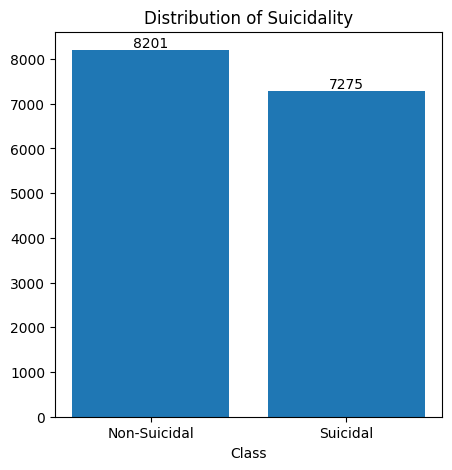

In [ ]:
fig, ax = plt.subplots(figsize=[5,5])
bars = ax.bar(x=label_count.index, height=label_count)
ax.bar_label(bars)
ax.set_title("Distribution of Suicidality")
ax.set_xlabel("Class")

There is around a 1,000 instance difference between classes, which is mild and does not require correction.

#### **Missing Data Check**

We noticed earlier that the `post` feature has missing values. We look into these instances to decide how to handle them.

In [ ]:
missing_post = df[df["post"].isna()]

missing_post

,title,post,label
1007,Just a very important reminder for everyone to...,NaN,Non-Suicidal
1009,Does this count as a cat?,NaN,Non-Suicidal
1016,I bought a pumpkin for £20 and made it into a ...,NaN,Non-Suicidal
1097,Girlfriends grandmother is a great artist and ...,NaN,Non-Suicidal
1146,"My daughter's thrift store Joker costume, I th...",NaN,Non-Suicidal
...,...,...,...
15397,How to get over fear of death?,NaN,Suicidal
15413,I don't deserve to be alive im dumb haha,NaN,Suicidal
15416,Is anyone up to talk?,NaN,Suicidal
15451,I don't want to wait until I grow up. Why suff...,NaN,Suicidal


In [ ]:
missing_post.value_counts(subset="label")

label
Non-Suicidal    765
Suicidal        469
Name: count, dtype: int64

Among the instances with missing posts, more of them are non-suicidal. To retain as much information as possible, we handle missing values as follows:
- A `has_post` binary indicator is added to flag whether an instance has post content, as the absence of a post body may itself carry signal for classification.
- Missing post values are filled with an empty string to allow downstream text processing.

In [ ]:
# Track which instance has posts
df["has_post"] = (~df["post"].isna()).astype(int) # Modeling purpose, having no post might be informational in the classification.

In [ ]:
# Fill missing post with empty string
df["post"] = df["post"].fillna("")

##### Sanity Check

We verify that missing values are properly filled.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15476 entries, 0 to 15475
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   title     15476 non-null  str  
 1   post      15476 non-null  str  
 2   label     15476 non-null  str  
 3   has_post  15476 non-null  int64
dtypes: int64(1), str(3)
memory usage: 483.8 KB


Each column now has equal non-null values, confirming the fill was successful.

#### **Duplicated Data Check**

We validate whether the duplicated titles and posts observed earlier represent true duplicate records.

In [ ]:
duplicated_values = df[df[["title", "post"]].duplicated()] # text is the combined title and post
duplicated_values

,title,post,label,has_post


There are no fully duplicated records when both title and post are considered together.

To further validate, we inspect a sample duplicated title and its corresponding posts.

In [ ]:
duplicated_title_test = df[df["title"].duplicated()]["title"].iloc[0]
duplicated_title_test

'I quit my job today.'

In [ ]:
df[df["title"] == duplicated_title_test]

,title,post,label,has_post
188,I quit my job today.,I work for an agency and they've sent me to so...,Non-Suicidal,1
495,I quit my job today.,I quit my job today. Only lasted 4 months. But...,Non-Suicidal,1


Even if the title is the same, these are two different posts with different content.

We do the same for duplicated post content.

In [ ]:
duplicated_post_test = df[df["post"].duplicated() & (df["post"] != "")]["post"].iloc[0]
duplicated_post_test

'.'

We look into these period posts.

In [ ]:
df[df["post"] == duplicated_post_test]

,title,post,label,has_post
1929,I wish I didn't have to age.,.,Non-Suicidal,1
8971,"I am supposed to be treated and I was happy,so...",.,Suicidal,1
10409,Hanging myself tonight so I avoid my birthday ...,.,Suicidal,1
12441,Just mixed Alprazolam with the Alchohol,.,Suicidal,1
14324,I noticed that I was on a downward spiral back...,.,Suicidal,1
15288,Why do good people die early,.,Suicidal,1


Some posters place their full message in the title and leave the post body as a single period. These are not meaningful post content and should be treated as no-post instances.

In [ ]:
period_posts = df[df["post"] == "."]
period_posts

,title,post,label,has_post
1929,I wish I didn't have to age.,.,Non-Suicidal,1
8971,"I am supposed to be treated and I was happy,so...",.,Suicidal,1
10409,Hanging myself tonight so I avoid my birthday ...,.,Suicidal,1
12441,Just mixed Alprazolam with the Alchohol,.,Suicidal,1
14324,I noticed that I was on a downward spiral back...,.,Suicidal,1
15288,Why do good people die early,.,Suicidal,1


In [ ]:
df.loc[period_posts.index, "has_post"] = 0
df.loc[period_posts.index, "post"] = ""

##### Sanity Check

We verify that the period posts were properly cleaned.

In [ ]:
df.loc[period_posts.index,:].head()

,title,post,label,has_post
1929,I wish I didn't have to age.,,Non-Suicidal,0
8971,"I am supposed to be treated and I was happy,so...",,Suicidal,0
10409,Hanging myself tonight so I avoid my birthday ...,,Suicidal,0
12441,Just mixed Alprazolam with the Alchohol,,Suicidal,0
14324,I noticed that I was on a downward spiral back...,,Suicidal,0


Each previously period post now has an empty post body and is labeled as no post.

#### **Incorrect Data Check**

We inspect a small random sample to manually validate the content of the posts and identify any remaining text quality issues. Since the task requires as much context as possible, we will not apply aggressive semantic cleaning such as stop word removal.

In [ ]:
data_sample = df.sample(20, random_state=random_seed) # Sample of 20
data_sample

,title,post,label,has_post
1459,Having a platonic female friend is one of the ...,I'm a straight guy but I met this female frien...,Non-Suicidal,1
13959,I am thinking of ending my life sooner or later.,I am 15 and i don’t see myself in another 10 y...,Suicidal,1
930,Started Dieting a few months ago and just star...,Early 30's guy and hit my peak of 335 lbs (152...,Non-Suicidal,1
12816,I just can’t,I don’t know anymore. This is just a vent so i...,Suicidal,1
4304,I hit 1 year clean from my eating disorder !,I’m genuinely shocked and happy that I’ve went...,Non-Suicidal,1
14618,The desire to kill myself is like a itch I nee...,I honestly can't take life anymore.\nI'm not s...,Suicidal,1
2927,I drank tap water!,"I have contamination OCD, along with comorbidi...",Non-Suicidal,1
12542,"Going to kill myself tomorrow or so, I failed ...",My comment on r /furby got 3 downvotes. These ...,Suicidal,1
5456,"I am almost out of dishwasher pods, but the ne...",,Non-Suicidal,0
99,"In the third week, of the third month, of the ...",It’s not the third day of the week but it is T...,Non-Suicidal,1


In [ ]:
for i in list(data_sample.index):
    title = data_sample.loc[i, "title"]
    post = data_sample.loc[i, "post"]
    label = data_sample.loc[i, "label"]
    
    print(f"Post {i+1} ({label}): {title}\n{post}\n\n")

Post 1460 (Non-Suicidal): Having a platonic female friend is one of the best things that happened to me
I'm a straight guy but I met this female friend a while ago and I gotta say it's one of the best things ever. Unlike most of my male friends, we talk about our feelings and we give emotional support to each other. She tells me she loves me all the time and I just feel warm talking to her. It's so good to have someone like this, as long as you can move past any jealously or romantic intentions.


Post 13960 (Suicidal): I am thinking of ending my life sooner or later.
I am 15 and i don’t see myself in another 10 years. I never had dreams. I never had aspirations. I never had goals because i never thought i’d live long enough to fulfill them. I don’t want to live in the state of my body right now. I cannot keep doing this.i also need painless suicide methods. I am not afraid of killing myself but i am afraid of surviving a suicide attempt. Suicide may seems as a selfish act for most of 

From this sample, several observations are noted:
- Posts contain explicit escape characters such as `\n` and `\t`, creating inconsistent spacing.
- Some posts reference external sources including other subreddits and external URLs.
- Posts use emoticons such as `:( :) <3 </3`, which carry emotional signal and will be retained.
- Non-suicidal posts make more use of exclamation and question marks.

The escape characters and external links warrant cleaning. Emoticons and punctuation are retained as they have semantic value for classification.

#### **Text Cleaning**

We create a combined `text` column by concatenating `title` and `post`. All subsequent cleaning is applied to this column, which will serve as the foundation for encoding tasks.

In [ ]:
df["text"] = df["title"] + " " + df["post"]

**Escape characters.** We identify and remove explicit escape sequences such as `\n` and `\t`, and normalize excess whitespace.

In [ ]:
re_escape = r"\\[A-Za-z]"
re_backslash= r"\\"
re_spaces = r"\s+" # \s matches any whitespace character

In [ ]:
def get_escape_chars_count(text: str):
    count = len(re.findall(re_escape, text))
    count += len(re.findall(re_backslash, text))
    count += text.count("\\n")

    return count

In [ ]:
escape_count = df["text"].map(get_escape_chars_count).sum()
escape_count

np.int64(402)

Escape characters are present in the dataset. We apply a cleaning function to remove them.

In [ ]:
def remove_escape_chars(text):
    cleaned_text = re.sub(re_escape, " ", text) # Remove excape characters
    cleaned_text = re.sub(re_backslash, "", cleaned_text) # Remove backslashes for symbols (\*, \\)
    cleaned_text = re.sub(re_spaces, " ", cleaned_text).strip()

    return cleaned_text

In [ ]:
df["text_cleaned"] = df["text"].map(remove_escape_chars)

##### Sanity Check

In [ ]:
escape_count = df["text_cleaned"].map(get_escape_chars_count).sum()
escape_count

np.int64(0)

All escape characters have been removed.

**External links.** External links can be URLs or subreddit references. Rather than removing them entirely, we replace them with generic tags (`<URL>` and `<SUBREDDIT>`). This preserves the information that an external reference exists while preventing sparse URL tokens from polluting the vocabulary.

Subreddit references carry additional value: mentions of mental-health-related subreddits may correlate with suicidal content. We extract these as separate features before replacing the references.

In [ ]:
re_links = r"https?:\/\/\S+|www\.\S+" # http, https, or www
re_subreddits = r"\br\/\s*(\w+)"

In [ ]:
def get_external_links(text):
    count = len(re.findall(re_links, text))
    count += len(re.findall(re_subreddits, text))

    return count

In [ ]:
external_count = df["text_cleaned"].map(get_external_links).sum()
external_count

np.int64(503)

External links are present in the dataset. We extract subreddit features before replacing all links with tags.

In [ ]:
def get_subreddits(text):
    subreddits = re.findall(re_subreddits, text)
    return subreddits

In [ ]:
def extract_subreddit_features(text_col: pd.Series):
    # List of popular subreddits and their category
    mental_health_subs = {'suicidewatch', 'depression', 'anxiety', 'mentalhealth', 
                      'selfharm', 'bipolar', 'ptsd', 'bpd', 'cptsd',
                      'suicidebereavement', 'griefsupport'}
    dark_subs = {'death', 'morbidquestions', 'morbidreality', 'watchpeopledie',
                'darkjokes', 'nihilism'}
    support_subs = {'offmychest', 'trueoffmychest', 'confession', 'advice',
                    'relationships', 'amitheasshole'}
    
    features = pd.DataFrame()

    # Get the subreddits per instance.
    subs = text_col.map(get_subreddits)

    features["sub_metal_health_count"] = subs.map(lambda x : sum(1 for s in x if s in mental_health_subs))
    features["sub_dark_count"] = subs.map(lambda x : sum(1 for s in x if s in dark_subs))
    features["sub_support_count"] = subs.map(lambda x : sum(1 for s in x if s in support_subs))
    features["sub_total_count"] = subs.map(lambda x : len(x))
    
    return features

In [ ]:
features = extract_subreddit_features(df["text_cleaned"]) # Features extracted from clean
features.sum()

sub_metal_health_count      6
sub_dark_count              0
sub_support_count           2
sub_total_count           171
dtype: int64

There are 171 subreddit mentions, with 8 belonging to the mental health, dark, or support categories. These are retained as features.

We place these as features to our dataset so we can retain the information for these subreddits.

In [ ]:
df = pd.concat([df, features], axis=1)
df

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,0,0,0,0
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,0,0,0,0
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",0,0,0,0
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",0,0,0,0
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
15471,"Once I die, I can finally be at rest.","My past actions will no longer haunt me, hopef...",Suicidal,1,"Once I die, I can finally be at rest. My past ...","Once I die, I can finally be at rest. My past ...",0,0,0,0
15472,I just want to stop.,I just want to stop living. I’ve lost everythi...,Suicidal,1,I just want to stop. I just want to stop livin...,I just want to stop. I just want to stop livin...,0,0,0,0
15473,I’m still alive,WHY THE FUCK AM I STILL ALIVE. WHY WONT I JUST...,Suicidal,1,I’m still alive WHY THE FUCK AM I STILL ALIVE....,I’m still alive WHY THE FUCK AM I STILL ALIVE....,0,0,0,0
15474,I'm lonely but I can't stand people,"It's a lot better online, but irl I can't stan...",Suicidal,1,I'm lonely but I can't stand people It's a lot...,I'm lonely but I can't stand people It's a lot...,0,0,0,0


We then replace external links with their respective tags.

In [ ]:
def remove_external_links(text):
    cleaned_text = re.sub(re_links, "<URL>", text)
    cleaned_text = re.sub(re_subreddits, "<SUBREDDIT>", cleaned_text)

    return cleaned_text

In [ ]:
df["text_cleaned"] = df["text_cleaned"].map(remove_external_links)

##### Sanity Check

In [ ]:
df["text_cleaned"].map(get_external_links).sum()

np.int64(0)

All URLs and subreddit mentions have been replaced with generic tags. We verify with an example.

In [ ]:
# Instance with external links 
external_idx = df[df["text_cleaned"].str.contains(r"<URL>", regex=True)].index
external_idx

Index([   37,    58,    81,    91,    93,   161,   162,   171,   181,   205,
       ...
        9968, 10017, 10054, 10106, 10236, 10237, 10515, 11151, 13138, 14132],
      dtype='int64', length=198)

In [ ]:
external_first_inst = df.loc[external_idx, ["text", "text_cleaned"]].iloc[0]
print("Original: \n" + external_first_inst["text"])
print("\n")
print("Cleaned: \n" + external_first_inst["text_cleaned"])

Original: 
I created a playlist of 1.868 songs that various subreddits consider to be "perfect" songs. Give me a number and I'll give you the song. I made a playlist of 1.868 songs that different subreddits consider "perfect" songs. The playlist is a mixed genre playlist of songs considered perfect by fans of the genres and artists. I have discovered new music based on their suggestions and thought I'd share.

Give me a number and I'll give you the song. If you think any songs should be added, feel free to let me know.

# EDIT: Here is the link to playlist on Spotify: [https://open.spotify.com/playlist/2W65j9V0DjVqlm9saRb3uO?si=556484e983fd41d6](https://open.spotify.com/playlist/2W65j9V0DjVqlm9saRb3uO?si=556484e983fd41d6)

# EDIT 2: Two Redditors made a playlist on Apple Music as well as Tidal with all of the songs. Here are the the links

# [https://music.apple.com/at/playlist/perfect-songs-of-all-genres-according-to-reddit-in/pl.u-47xbCaykJra](https://music.apple.com/at/playlist/perf

Links are now properly handled in the cleaned text.

### **Feature Engineering**

The dataset in its raw form contains only title and post text. While this is sufficient for context-sensitive models, traditional machine learning algorithms benefit from structured numerical features. We derive features that capture the linguistic and stylistic signals most relevant to suicidality detection.

Most redditors convey emotion in one of four ways:
- **Structure:** Uppercase words and expressive punctuation (e.g., `!!!`, `???`)
- **Reflecting words:** Vocabulary associated with depression, hopelessness, or self-harm
- **Imagery:** Emojis and emoticons
- **Context:** Implicit meaning that depends on surrounding text

Context is difficult to capture word-by-word. We address it through encoding strategies such as TF-IDF and BERT embeddings in the classification stage. The features derived here focus on the first three.

In [ ]:
df.head()

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,0,0,0,0
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,0,0,0,0
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",0,0,0,0
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",0,0,0,0
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,0,0,0,0


#### **Uppercase Features**

People often display strong emotions through uppercase typing. We extract the count of uppercase words and their ratio relative to total words. These features capture how often uppercase words appear, potentially indicating heightened emotional intensity.

Each feature derivation is encapsulated in a function within the `feature_engineering.py` module, allowing reuse and consistent application across splits.

In [ ]:
df["text_cleaned"].head().iloc[0]

"I'm looking for a girl I've met at the Polish airport to thank her properly! I've tried Polish spotted pages but I guess she isn't there. But I know she's active on this sub so... WHY THE HELL NOT? If you see this - you don't need to let me know. Just read it. I just want to thank you for not being indifferent. 2 weeks ago I was in a very bad place. My gf broke up with me just before I got into the plane and I landed just to find out my luggage got lost and like the last idiot I had there my cards and money. And I don't know Polish language. Like a real, adult man, I just sat there and cried like a baby, exhausted after very long trip. That Polish girl came already holding a cup with hot chocolate for me, asking if she could help in any way. We talked, she helped me with the luggage, helped me with the directions to my hotel and gave me money to get there. And we started talking about random things (like reddit) and for that I'm very thankful, you distracted me. I can't express how gr

In [ ]:
df["text_cleaned"].map(extract_case_features).head().iloc[0]

(4, 0.017391304347826087)

The function returns the uppercase word count and the ratio of uppercase words to total words.

In [ ]:
features = pd.DataFrame()
features["upper_count"], features["upper_ratio"] = zip(*df["text_cleaned"].map(extract_case_features))
features = pd.concat([features, df["label"]], axis=1)

uppercase_per_label = features.groupby("label").agg({"upper_count": "sum", "upper_ratio": "mean"})
uppercase_per_label

,upper_count,upper_ratio
label,,
Non-Suicidal,7161,0.009066
Suicidal,8185,0.008691


Text(0.5, 0.98, 'Uppercase_count and Ratio per Label')

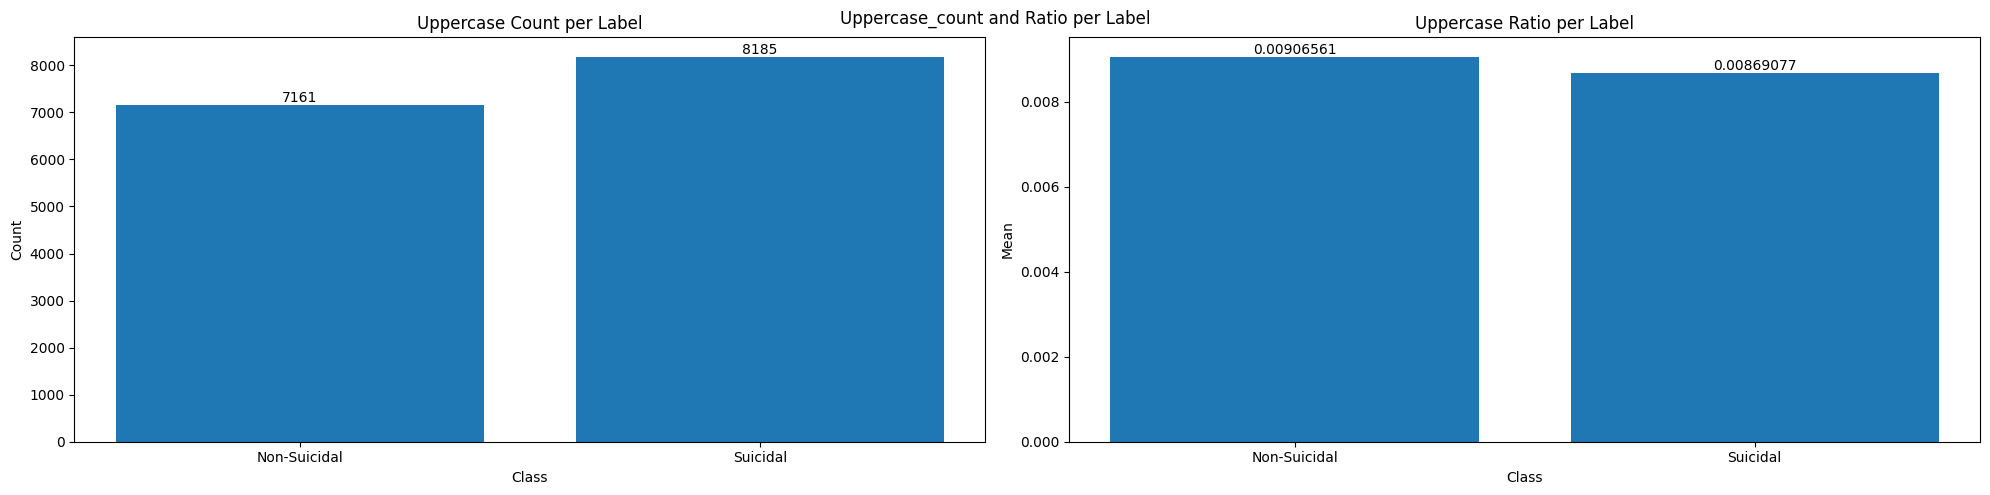

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

count_bars = ax[0].bar(x=uppercase_per_label["upper_count"].index, height=uppercase_per_label["upper_count"])
ax[0].bar_label(count_bars)
ax[0].set_title("Uppercase Count per Label")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Count")

ratio_bars = ax[1].bar(x=uppercase_per_label["upper_ratio"].index, height=uppercase_per_label["upper_ratio"])
ax[1].bar_label(ratio_bars)
ax[1].set_title("Uppercase Ratio per Label")
ax[1].set_xlabel("Class")
ax[1].set_ylabel("Mean")

fig.tight_layout()
fig.suptitle("Uppercase_count and Ratio per Label")

Non-suicidal posts have higher total uppercase word counts, though the ratio per post is similar across classes. Uppercase usage carries some signal and is retained. However, to reduce noise for traditional ML models, a separate lowercase version of the text will be used for TF-IDF vectorization. The uppercase counts and ratios are kept as separate features.

#### **Punctuation Features**

We track exclamation (`!`) and question (`?`) marks specifically. Exclamation marks often reflect strong emotion. Question marks may indicate advice-seeking behavior, which appears more frequently in non-suicidal posts. Whether more or less of these punctuations correlates with suicidality is a pattern the models will learn.

In [ ]:
suicidal = df[df["label"] == "Suicidal"]
non_suicidal = df[df["label"] == "Non-Suicidal"]

In [ ]:
punctuation_count_suicidal = suicidal["text_cleaned"].str.count(r"\?|!")
punctuation_count_suicidal.describe()

count    7275.000000
mean        0.821306
std         3.076419
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max       155.000000
Name: text_cleaned, dtype: float64

In [ ]:
punctuation_count_nonsuicidal = non_suicidal["text_cleaned"].str.count(r"\?|!")
punctuation_count_nonsuicidal.describe()

count    8201.000000
mean        1.863919
std         9.198556
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max       502.000000
Name: text_cleaned, dtype: float64

Punctuation marks are used sparingly in both classes, though both contain notable outliers. The distribution is highly right-skewed, confirming that most posts use few punctuation marks but a small subset uses them heavily.

#### **Reflecting Words Features**

The most direct indicator of emotional state is vocabulary. For suicidality detection, we track word categories grounded in prior research:

| Feature | Research Basis |
|---|---|
| **First-person singular pronouns** | Rude, Gortner and Pennebaker (2004) — elevated "I-talk" reflects self-focused attention associated with depression |
| **First-person plural pronouns** | Captured as a contrast feature to singular pronoun usage |
| **Absolutist words** | Al-Mosaiwi and Johnstone (2018) — absolutist language is highest in suicidal ideation, more specific than negative emotion words alone |
| **Negative emotion words** | LIWC Negemo category (Pennebaker et al.) — standard lexicon for computational detection of emotional distress |
| **Death-related words** | Coppersmith, Dredze and Harman (2014) — direct suicidality markers including explicit references to death and self-harm |
| **Past tense verbs** | Associated with retrospective framing common in depression narratives |

In [ ]:
# Pronoun features
first_person_singular = r"\b(I(?:'|')?(?:m|ve|ll|d)?|me|my|mine|myself)\b"
first_person_plural = r"\b(we(?:'|')?(?:re|ve|ll|d)?|us|our|ours|ourselves)\b"

# Absolutist words (Obtained from paper)
absolutist = r"\b(absolutely|all|always|complete|completely|constant|constantly|definitely|entire|entirely|ever|every|everyone|everything|full|must|never|nothing|totally|whole)\b"

# Negative emotion 
negative = r"\b(sad|miserable|unhappy|depressed|hopeless|worthless|alone|lonely|hurt|pain|suffer|cry|tears|awful|terrible|horrible)\b"

# Death-related 
death = r"\b(death|die|dead|dying|suicide|suicidal|kill|killed|killing|end|ending|struggle|struggling)\b"

# Past tense 
past_tense = r"\b(was|were|had|did|been)\b" # Shows reminiscing/reflection

The `extract_word_features` function counts occurrences of each word category per post.

In [ ]:
features = extract_word_features(df["text_cleaned"])

features

,first_person_singular,first_person_plural,absolutist_count,negative_emotion,death_related,past_tense
0,27,2,0,0,0,3
1,15,3,0,0,0,5
2,4,2,2,0,0,0
3,55,4,9,0,0,2
4,15,3,2,0,0,4
...,...,...,...,...,...,...
15471,5,0,1,1,1,0
15472,19,0,7,0,0,0
15473,22,0,1,2,5,2
15474,38,0,7,3,0,0


This gives us a count of how prominent each category of emotionally relevant language is in each instance.

#### **Emoji and Emoticon Features**

Redditors use emojis and emoticons to reinforce or sometimes contradict the emotional tone of their posts. We extract these as separate feature categories using the `emoji` library for Unicode emojis and regex patterns for text emoticons. Features are grouped by sentiment category: positive, negative, crying, neutral, heart, broken heart, and crisis-related.

In [ ]:
df["text_cleaned"].map(lambda x : list(emoji.analyze(x))).sum()

[Token(chars='🙃', value=EmojiMatch(🙃, 486:487)),
 Token(chars='😂', value=EmojiMatch(😂, 691:692)),
 Token(chars='🥳', value=EmojiMatch(🥳, 26:27)),
 Token(chars='🎉', value=EmojiMatch(🎉, 121:122)),
 Token(chars='😂', value=EmojiMatch(😂, 1739:1740)),
 Token(chars='😂', value=EmojiMatch(😂, 1817:1818)),
 Token(chars='😊', value=EmojiMatch(😊, 1108:1109)),
 Token(chars='💜', value=EmojiMatch(💜, 273:274)),
 Token(chars='✌️', value=EmojiMatch(✌️, 274:276)),
 Token(chars='💜', value=EmojiMatch(💜, 1863:1864)),
 Token(chars='✌️', value=EmojiMatch(✌️, 1864:1866)),
 Token(chars='😂', value=EmojiMatch(😂, 1331:1332)),
 Token(chars='😭', value=EmojiMatch(😭, 1359:1360)),
 Token(chars='🥩', value=EmojiMatch(🥩, 3406:3407)),
 Token(chars='😭', value=EmojiMatch(😭, 156:157)),
 Token(chars='😭', value=EmojiMatch(😭, 157:158)),
 Token(chars='😄', value=EmojiMatch(😄, 806:807)),
 Token(chars='🙃', value=EmojiMatch(🙃, 905:906)),
 Token(chars='💀', value=EmojiMatch(💀, 2575:2576)),
 Token(chars='🥲', value=EmojiMatch(🥲, 846:847)),


Emojis are present in the dataset. We also confirm the presence of text emoticons.

In [ ]:
positive_pattern = r"(?:^|\s)(:\)|:D|;\)|=\)|:-\)|:\]|=D|:>|8\))(?=\s|$)"

df["text_cleaned"].map(lambda x : len(re.findall(positive_pattern, x))).sum()

np.int64(694)

Using the `extract_emoji_features` and `extract_emoticon_features` functions, we return counts for each category.

In [ ]:
df["text_cleaned"].map(extract_emoji_features)

0        (0, 0, 0, 0)
1        (0, 0, 0, 0)
2        (0, 0, 0, 0)
3        (0, 0, 0, 0)
4        (0, 0, 0, 0)
             ...     
15471    (0, 0, 0, 0)
15472    (0, 0, 0, 0)
15473    (0, 0, 0, 0)
15474    (0, 0, 0, 0)
15475    (0, 0, 0, 0)
Name: text_cleaned, Length: 15476, dtype: object

In [ ]:
df["text_cleaned"].map(extract_emoticon_features)

0        (0, 0, 0, 0, 0, 0)
1        (0, 0, 0, 0, 0, 0)
2        (0, 0, 0, 0, 0, 0)
3        (1, 0, 0, 0, 0, 0)
4        (1, 0, 0, 0, 0, 0)
                ...        
15471    (0, 0, 0, 0, 0, 0)
15472    (0, 0, 0, 0, 0, 0)
15473    (0, 0, 0, 0, 0, 0)
15474    (0, 0, 0, 0, 0, 0)
15475    (0, 0, 0, 0, 0, 0)
Name: text_cleaned, Length: 15476, dtype: object

#### **Context**

Context-dependent meaning is difficult to capture through word-level feature extraction. Posts where individual words appear neutral but the overall meaning signals distress fall outside the scope of these engineered features. This limitation motivates the use of BERT-based embeddings and fine-tuning in the classification stage, where the model can attend to full sequence context rather than isolated tokens.

#### **Combining All Features**

We apply all feature extraction functions together using `extract_all_features` and concatenate the results with the existing dataset.

In [ ]:
df.head()

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,0,0,0,0
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,0,0,0,0
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",0,0,0,0
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",0,0,0,0
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,0,0,0,0


In [ ]:
features = extract_all_features(df["text_cleaned"])

features.head()

In [ ]:
df = pd.concat([df, features], axis=1)
df.to_csv("suicidality_dataset_w_features.csv")

---

## **Exploratory Data Analysis**

In [ ]:
df = pd.read_csv("suicidality_dataset_w_features.csv", keep_default_na=False, index_col=0)

Before statistical analysis, we first verify dataset structure, size, and class balance so later findings are more trustworthy for classification.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15476 entries, 0 to 15475
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    15476 non-null  str    
 1   post                     15476 non-null  str    
 2   label                    15476 non-null  str    
 3   has_post                 15476 non-null  int64  
 4   text                     15476 non-null  str    
 5   text_cleaned             15476 non-null  str    
 6   sub_metal_health_count   15476 non-null  int64  
 7   sub_dark_count           15476 non-null  int64  
 8   sub_support_count        15476 non-null  int64  
 9   sub_total_count          15476 non-null  int64  
 10  first_person_singular    15476 non-null  int64  
 11  first_person_plural      15476 non-null  int64  
 12  absolutist_count         15476 non-null  int64  
 13  negative_emotion         15476 non-null  int64  
 14  death_related            15476 no

We also compute word count per instance as a reference variable for feature normalization and length-based interpretation.

In [ ]:
df["word_count"] = df["text_cleaned"].map(lambda x : len(x.split(" ")))
df["word_count"]

0        230
1        202
2         80
3        499
4        184
        ... 
15471     28
15472    124
15473    121
15474    256
15475    179
Name: word_count, Length: 15476, dtype: int64

In [ ]:
print("### Dataset Statistics\n")
print(f"**Class Distribution:**")
print(df['label'].value_counts())
print(f"\n**Class Balance:** {df['label'].value_counts(normalize=True).round(3).to_dict()}")

print(f"\n**Text Length Statistics:**")
print(f"- Mean word count: {df['word_count'].mean():.1f} words")
print(f"- Median word count: {df['word_count'].median():.1f} words")
print(f"- Range: {df['word_count'].min()}-{df['word_count'].max()} words")

print(f"\n**Feature Statistics:**")
print(f"- Posts with death-related terms: {(df['death_related'] > 0).sum()} ({(df['death_related'] > 0).mean()*100:.1f}%)")
print(f"- Posts with first-person singular: {(df['first_person_singular'] > 0).sum()} ({(df['first_person_singular'] > 0).mean()*100:.1f}%)")
print(f"- Posts with emoticons: {((df['emoticon_positive'] + df['emoticon_negative'] + df['emoticon_crying']) > 0).sum()}")
print(f"- Posts with emojis: {((df['emoji_negative'] + df['emoji_positive']) > 0).sum()}")

### Dataset Statistics

**Class Distribution:**
label
Non-Suicidal    8201
Suicidal        7275
Name: count, dtype: int64

**Class Balance:** {'Non-Suicidal': 0.53, 'Suicidal': 0.47}

**Text Length Statistics:**
- Mean word count: 143.0 words
- Median word count: 94.0 words
- Range: 1-4190 words

**Feature Statistics:**
- Posts with death-related terms: 5981 (38.6%)
- Posts with first-person singular: 15093 (97.5%)
- Posts with emoticons: 680
- Posts with emojis: 546


To anchor the feature analysis in real language patterns, we preview sample posts and inspect representative instances from both classes.

In [ ]:
df.head(5)

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count,...,emoticon_negative,emoticon_crying,emoticon_neutral,emoticon_heart,emoticon_broken_heart,emoji_negative,emoji_positive,emoji_crisis,emoji_implicit_distress,word_count
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,230
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,202
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",0,0,0,0,...,0,0,0,0,0,0,0,0,0,80
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",0,0,0,0,...,0,0,0,0,0,0,0,0,0,499
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,184


In [ ]:
print("=" * 60)
print("SUICIDAL POSTS — 3 RANDOM SAMPLES")
print("=" * 60)
suicidal_samples = df[df['label'] == 'Suicidal']['text'].sample(3, random_state=42)
for i, text in enumerate(suicidal_samples, 1):
    print(f"\nSample {i}:\n{text[:300]}")
    print("-" * 60)

print("\n")
print("=" * 60)
print("NON-SUICIDAL POSTS — 3 RANDOM SAMPLES")
print("=" * 60)
non_suicidal_samples = df[df['label'] == 'Non-Suicidal']['text'].sample(3, random_state=42)
for i, text in enumerate(non_suicidal_samples, 1):
    print(f"\nSample {i}:\n{text[:300]}")
    print("-" * 60)

SUICIDAL POSTS — 3 RANDOM SAMPLES

Sample 1:
I feel like keeping myself alive is delusional and I should just end it. I (31M) have been dealing with abuse since a child (emotionally,physically,sexually) from parents and peers growing up. I recently just gotten out of a really bad relationship (27F) they would always either physically abuse me 
------------------------------------------------------------

Sample 2:
I don’t want to die, but I don’t want to do any job, so the only solution is death. Im currently a first year undergrad student and I’m very happy with my university life right now. However, when I start thinking about my life post-graduation, having to do a full-time job, and even having to do a pa
------------------------------------------------------------

Sample 3:
FUCK FUCK me FUCK my dad FUCK my school FUCK my family FUCK EVERY FUCKING THING
------------------------------------------------------------


NON-SUICIDAL POSTS — 3 RANDOM SAMPLES

Sample 1:
Took myself to Ol

From this preview, we can observe key patterns:
- Suicidal posts often contain direct or indirect self-harm references and stronger emotional intensity.
- Some non-suicidal posts still contain negative words, but context shows that distress alone does not always imply suicidal ideation.

This second observation is important: **negative emotion is not enough**. A post can be emotionally heavy, about a breakup, a failed exam, a hard day, without any suicidal ideation. This means the classification task requires understanding the *type* and *combination* of language used, not just its emotional tone. That is the central question driving the analysis below.

### Labels

Before comparing features across classes, we verify class distribution. Severe imbalance would distort statistical comparisons and require correction before modeling.

In [ ]:
counts = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
print(balance_df)

              Count  Percentage (%)
label                              
Non-Suicidal   8201           52.99
Suicidal       7275           47.01


Text(0, 0.5, 'Count')

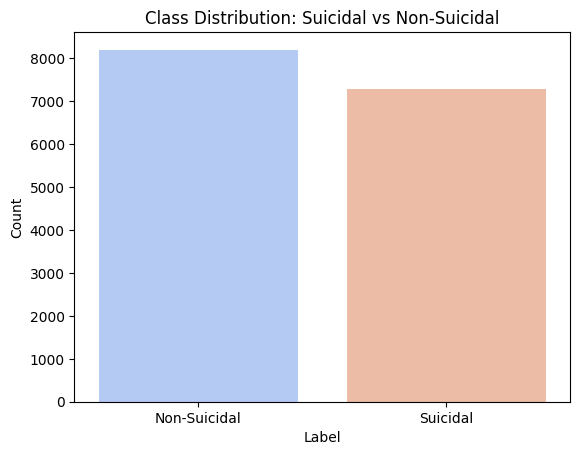

In [ ]:
sns.countplot(data=df, x='label', hue='label', palette='coolwarm', legend=False)
plt.title('Class Distribution: Suicidal vs Non-Suicidal')
plt.xlabel('Label')
plt.ylabel('Count')

### Dataset Summary
Total posts: 15,476 (7,275 Suicidal, 8,201 Non-Suicidal)  
Class split: 47.01% vs 52.99%  

**The dataset is reasonably balanced. Severe imbalance correction is not required, and feature comparisons are less likely to be dominated by label skew.**

---

### Normalization of Counts

The engineered features were intentionally not normalized during preprocessing to avoid leakage from full-dataset statistics before train/test splitting. For EDA only, we compute temporary normalized ratios to compare classes more fairly.

This matters because longer posts naturally accumulate more raw counts; without normalization, we risk attributing length effects to linguistic effects.

In [ ]:
df['word_count'] = df['text'].str.split().str.len()
print(df.groupby('label')['word_count'].mean())

label
Non-Suicidal    124.985855
Suicidal        163.210034
Name: word_count, dtype: float64


Suicidal posts average about **38 more words per post** than non-suicidal posts. This is a meaningful length difference, raw feature counts from suicidal posts would be inflated simply because those posts are longer, not necessarily because the features are more prevalent. We therefore normalize all count features by word count before any cross-class comparison.

In [ ]:
df.columns

Index(['title', 'post', 'label', 'has_post', 'text', 'text_cleaned',
       'sub_metal_health_count', 'sub_dark_count', 'sub_support_count',
       'sub_total_count', 'first_person_singular', 'first_person_plural',
       'absolutist_count', 'negative_emotion', 'death_related', 'past_tense',
       'exclamation_count', 'question_count', 'upper_word_count',
       'upper_word_ratio', 'emoticon_positive', 'emoticon_negative',
       'emoticon_crying', 'emoticon_neutral', 'emoticon_heart',
       'emoticon_broken_heart', 'emoji_negative', 'emoji_positive',
       'emoji_crisis', 'emoji_implicit_distress', 'word_count'],
      dtype='str')

In [ ]:
count_features = list(df.select_dtypes("int").loc[:, "first_person_singular":].columns)

count_features.remove("word_count")

for feature in count_features:
    df[f'{feature}_ratio'] = df[feature] / df['word_count']
    
rate_features = [f'{f}_ratio' for f in count_features]
print(df.groupby('label')[rate_features].mean())

              first_person_singular_ratio  first_person_plural_ratio  \
label                                                                  
Non-Suicidal                     0.102855                   0.006606   
Suicidal                         0.131494                   0.003228   

              absolutist_count_ratio  negative_emotion_ratio  \
label                                                          
Non-Suicidal                0.013578                0.001917   
Suicidal                    0.019514                0.006785   

              death_related_ratio  past_tense_ratio  exclamation_count_ratio  \
label                                                                          
Non-Suicidal             0.001405          0.019771                 0.016475   
Suicidal                 0.015611          0.011250                 0.003779   

              question_count_ratio  upper_word_count_ratio  \
label                                                        
Non-Suici

---

### EDA Questions

The sample preview raised a key observation: non-suicidal posts can carry strong negative emotion without any suicidal ideation. This means sentiment intensity alone is insufficient, the classification task demands understanding which specific linguistic signals, and which *combinations* of them, are truly predictive.

The three questions below build on each other. We first identify which features differ the most between classes (Q1), then ask whether those features work independently or together (Q2), and finally examine the cases where even the best features are expected to fail (Q3).

### Main Question

#### **How do linguistic and emotional patterns differ between suicidal and non-suicidal posts, and which features are most discriminative?**

### Subquestions
1. Which linguistic features show the strongest differences between classes?
2. Do suicidal posts exhibit distinct combinations of features?
3. What characteristics appear in distress-only posts and subtle suicidal posts that may cause classification errors?

---

### EDA Question 1: Which linguistic features show the strongest differences between classes?

We start with feature-level significance testing to identify which normalized linguistic markers best separate the two classes. These results guide feature prioritization for baseline classifiers and establish a reference point for model interpretation.

We compare class-wise means across all ratio features and test whether observed differences are statistically meaningful or likely due to chance.

In [ ]:
suicidal_rates = df[df["label"] == "Suicidal"].loc[:, rate_features]
suicidal_rates

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,question_count_ratio,upper_word_count_ratio,emoticon_positive_ratio,emoticon_negative_ratio,emoticon_crying_ratio,emoticon_neutral_ratio,emoticon_heart_ratio,emoticon_broken_heart_ratio,emoji_negative_ratio,emoji_positive_ratio,emoji_crisis_ratio,emoji_implicit_distress_ratio
8201,0.055556,0.006173,0.018519,0.000000,0.006173,0.024691,0.000000,0.000000,0.006173,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8202,0.141538,0.003077,0.021538,0.003077,0.006154,0.018462,0.003077,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8203,0.135965,0.000000,0.043860,0.008772,0.000000,0.017544,0.000000,0.000000,0.004386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8204,0.152778,0.000000,0.020833,0.011574,0.006944,0.016204,0.013889,0.004630,0.004630,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8205,0.097826,0.003623,0.014493,0.000000,0.003623,0.032609,0.003623,0.003623,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15471,0.178571,0.000000,0.035714,0.035714,0.035714,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15472,0.153226,0.000000,0.056452,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15473,0.181818,0.000000,0.008264,0.016529,0.041322,0.016529,0.000000,0.000000,0.140496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15474,0.148438,0.000000,0.027344,0.011719,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
non_suicidal_rates = df[df["label"] == "Non-Suicidal"].loc[:, rate_features]
non_suicidal_rates

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,question_count_ratio,upper_word_count_ratio,emoticon_positive_ratio,emoticon_negative_ratio,emoticon_crying_ratio,emoticon_neutral_ratio,emoticon_heart_ratio,emoticon_broken_heart_ratio,emoji_negative_ratio,emoji_positive_ratio,emoji_crisis_ratio,emoji_implicit_distress_ratio
0,0.117391,0.008696,0.000000,0.0,0.0,0.013043,0.004348,0.004348,0.017391,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.074257,0.014851,0.000000,0.0,0.0,0.024752,0.000000,0.004950,0.004950,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.050000,0.025000,0.025000,0.0,0.0,0.000000,0.000000,0.000000,0.050000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.110220,0.008016,0.018036,0.0,0.0,0.004008,0.000000,0.000000,0.000000,0.002004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.081522,0.016304,0.010870,0.0,0.0,0.021739,0.000000,0.005435,0.005435,0.005435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8196,0.120690,0.017241,0.000000,0.0,0.0,0.034483,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8197,0.074074,0.024691,0.000000,0.0,0.0,0.049383,0.000000,0.000000,0.012346,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8198,0.047945,0.006849,0.013699,0.0,0.0,0.027397,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8199,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.222222,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


To identify the significant difference of features, we use `Welch's t-test`.

#### Why we use a t-test here
We use a **Welch's independent-samples t-test** to evaluate whether mean feature differences between **Suicidal** and **Non-Suicidal** posts are statistically meaningful, not just random variation.

#### How it works
- It compares group means relative to within-group spread.
- **Null hypothesis ($H_0$):** both groups have the same true feature mean.
- **Alternative hypothesis ($H_1$):** the true means are different.
- It returns a **t-statistic** (standardized group difference) and a **p-value** (how likely that difference is under $H_0$).

#### Why Welch's version
Welch's test is preferred here because it is more robust when group variances are unequal and group sizes are not exactly identical.

#### Decision rule
If `p < 0.05`, we reject $H_0$ and conclude the feature differs significantly between classes. We also inspect **Cohen's d** to prioritize effects that are practically meaningful, not only statistically significant.

In [ ]:
def compare_feature(feature_name):
    """Compare single feature between classes."""
    suicidal_vals = df[df['label'] == 'Suicidal'][feature_name]
    non_suicidal_vals = df[df['label'] == 'Non-Suicidal'][feature_name]
    
    # T-test
    t_stat, p_value = stats.ttest_ind(suicidal_vals, non_suicidal_vals, equal_var=False)
    
    # Means
    mean_s = suicidal_vals.mean()
    mean_ns = non_suicidal_vals.mean()
    
    # Cohen's d
    pooled_std = np.sqrt((suicidal_vals.std()**2 + non_suicidal_vals.std()**2) / 2)
    cohens_d = (mean_s - mean_ns) / pooled_std
    
    return pd.Series({
        'Non-Suicidal Mean': mean_ns,
        'Suicidal Mean': mean_s,
        'Difference': mean_s - mean_ns,
        't-statistic': t_stat,
        'p-value': p_value,
        "Cohen's d": cohens_d
    })

# Apply to all features at once
stats_df = pd.DataFrame({
    feature: compare_feature(feature) 
    for feature in rate_features
}).T

stats_df['Significant'] = stats_df['p-value'] < 0.05

stats_df

,Non-Suicidal Mean,Suicidal Mean,Difference,t-statistic,p-value,Cohen's d,Significant
first_person_singular_ratio,0.102855,1.314943e-01,2.863962e-02,34.520052,3.277174e-251,0.557558,True
first_person_plural_ratio,0.006606,3.228059e-03,-3.378037e-03,-17.320994,1.458160e-66,-0.276423,True
absolutist_count_ratio,0.013578,1.951425e-02,5.935912e-03,17.840183,2.326854e-70,0.289970,True
negative_emotion_ratio,0.001917,6.785179e-03,4.867953e-03,25.466937,7.492841e-139,0.417409,True
death_related_ratio,0.001405,1.561062e-02,1.420560e-02,45.906770,0.000000e+00,0.758798,True
past_tense_ratio,0.019771,1.124961e-02,-8.520991e-03,-28.867977,2.499907e-178,-0.460394,True
exclamation_count_ratio,0.016475,3.778594e-03,-1.269630e-02,-6.431813,1.322840e-10,-0.105808,True
question_count_ratio,0.005038,6.151296e-03,1.112808e-03,3.657970,2.553658e-04,0.059775,True
upper_word_count_ratio,0.009066,8.690774e-03,-3.748366e-04,-0.413075,6.795581e-01,-0.006715,False
emoticon_positive_ratio,0.001168,5.867890e-05,-1.109797e-03,-13.832428,4.613569e-43,-0.216399,True


The full table includes features with varying levels of effect. We apply a practical filter: features must be both statistically significant and show a large effect size (|Cohen's d| > 0.5) to be considered strongly discriminative. This avoids over-indexing on features that are significant only because of sample size.

In [ ]:
# Strongly discriminative: significant AND large effect size
significant_features = stats_df[
    stats_df["Significant"] & 
    ((stats_df["Cohen's d"] > 0.1) | (stats_df["Cohen's d"] < -0.1))
].index

significant_features

Index(['first_person_singular_ratio', 'first_person_plural_ratio',
       'absolutist_count_ratio', 'negative_emotion_ratio',
       'death_related_ratio', 'past_tense_ratio', 'exclamation_count_ratio',
       'emoticon_positive_ratio', 'emoji_positive_ratio'],
      dtype='str')

In [ ]:
stats_df.loc[significant_features, ["p-value", "Cohen's d"]].sort_values("Cohen's d", ascending=False)

,p-value,Cohen's d
first_person_singular_ratio,3.277174e-251,0.557558
first_person_plural_ratio,1.458160e-66,-0.276423
absolutist_count_ratio,2.326854e-70,0.289970
negative_emotion_ratio,7.492841e-139,0.417409
death_related_ratio,0.000000e+00,0.758798
past_tense_ratio,2.499907e-178,-0.460394
exclamation_count_ratio,1.322840e-10,-0.105808
emoticon_positive_ratio,4.613569e-43,-0.216399
emoji_positive_ratio,9.129735e-18,-0.134565


Two features clear the large-effect threshold: **death-related terms** (d = 0.76) and **first-person singular pronouns** (d = 0.56). These are the strongest single-feature separators in the dataset.

However, several medium-effect features also carry meaningful signal and are worth noting:

| Feature | Cohen's d | Direction | Interpretation |
|---|---|---|---|
| `death_related_ratio` | 0.76 | Higher in Suicidal | Most discriminative feature; direct suicidality marker |
| `first_person_singular_ratio` | 0.56 | Higher in Suicidal | Self-focused narration associated with ideation |
| `past_tense_ratio` | -0.46 | Higher in Non-Suicidal | Reflective storytelling without ideation |
| `negative_emotion_ratio` | 0.42 | Higher in Suicidal | General distress, meaningful but not sufficient alone |
| `absolutist_count_ratio` | 0.29 | Higher in Suicidal | Rigid, black-and-white thinking patterns |
| `exclamation_count_ratio` | -0.11 | Higher in Non-Suicidal | Expressive intensity absent in suicidal posts |

The **exclamation mark finding is counterintuitive**: non-suicidal posts use exclamation marks more than the rate of suicidal posts. This makes sense on reflection, high emotional intensity in non-suicidal posts is often outward-facing (excitement, frustration, venting), while suicidal posts tend toward a quieter, although with some exceptions. Similarly, the **past tense** being more common in non-suicidal posts suggests reflective storytelling rather than present-tense distress.

In [ ]:
significant_subset = df.loc[:, [*significant_features, "label"]]
significant_subset

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,emoticon_positive_ratio,emoji_positive_ratio,label
0,0.117391,0.008696,0.000000,0.000000,0.000000,0.013043,0.004348,0.000000,0.0,Non-Suicidal
1,0.074257,0.014851,0.000000,0.000000,0.000000,0.024752,0.000000,0.000000,0.0,Non-Suicidal
2,0.050000,0.025000,0.025000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,Non-Suicidal
3,0.110220,0.008016,0.018036,0.000000,0.000000,0.004008,0.000000,0.002004,0.0,Non-Suicidal
4,0.081522,0.016304,0.010870,0.000000,0.000000,0.021739,0.000000,0.005435,0.0,Non-Suicidal
...,...,...,...,...,...,...,...,...,...,...
15471,0.178571,0.000000,0.035714,0.035714,0.035714,0.000000,0.000000,0.000000,0.0,Suicidal
15472,0.153226,0.000000,0.056452,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,Suicidal
15473,0.181818,0.000000,0.008264,0.016529,0.041322,0.016529,0.000000,0.000000,0.0,Suicidal
15474,0.148438,0.000000,0.027344,0.011719,0.000000,0.000000,0.000000,0.000000,0.0,Suicidal


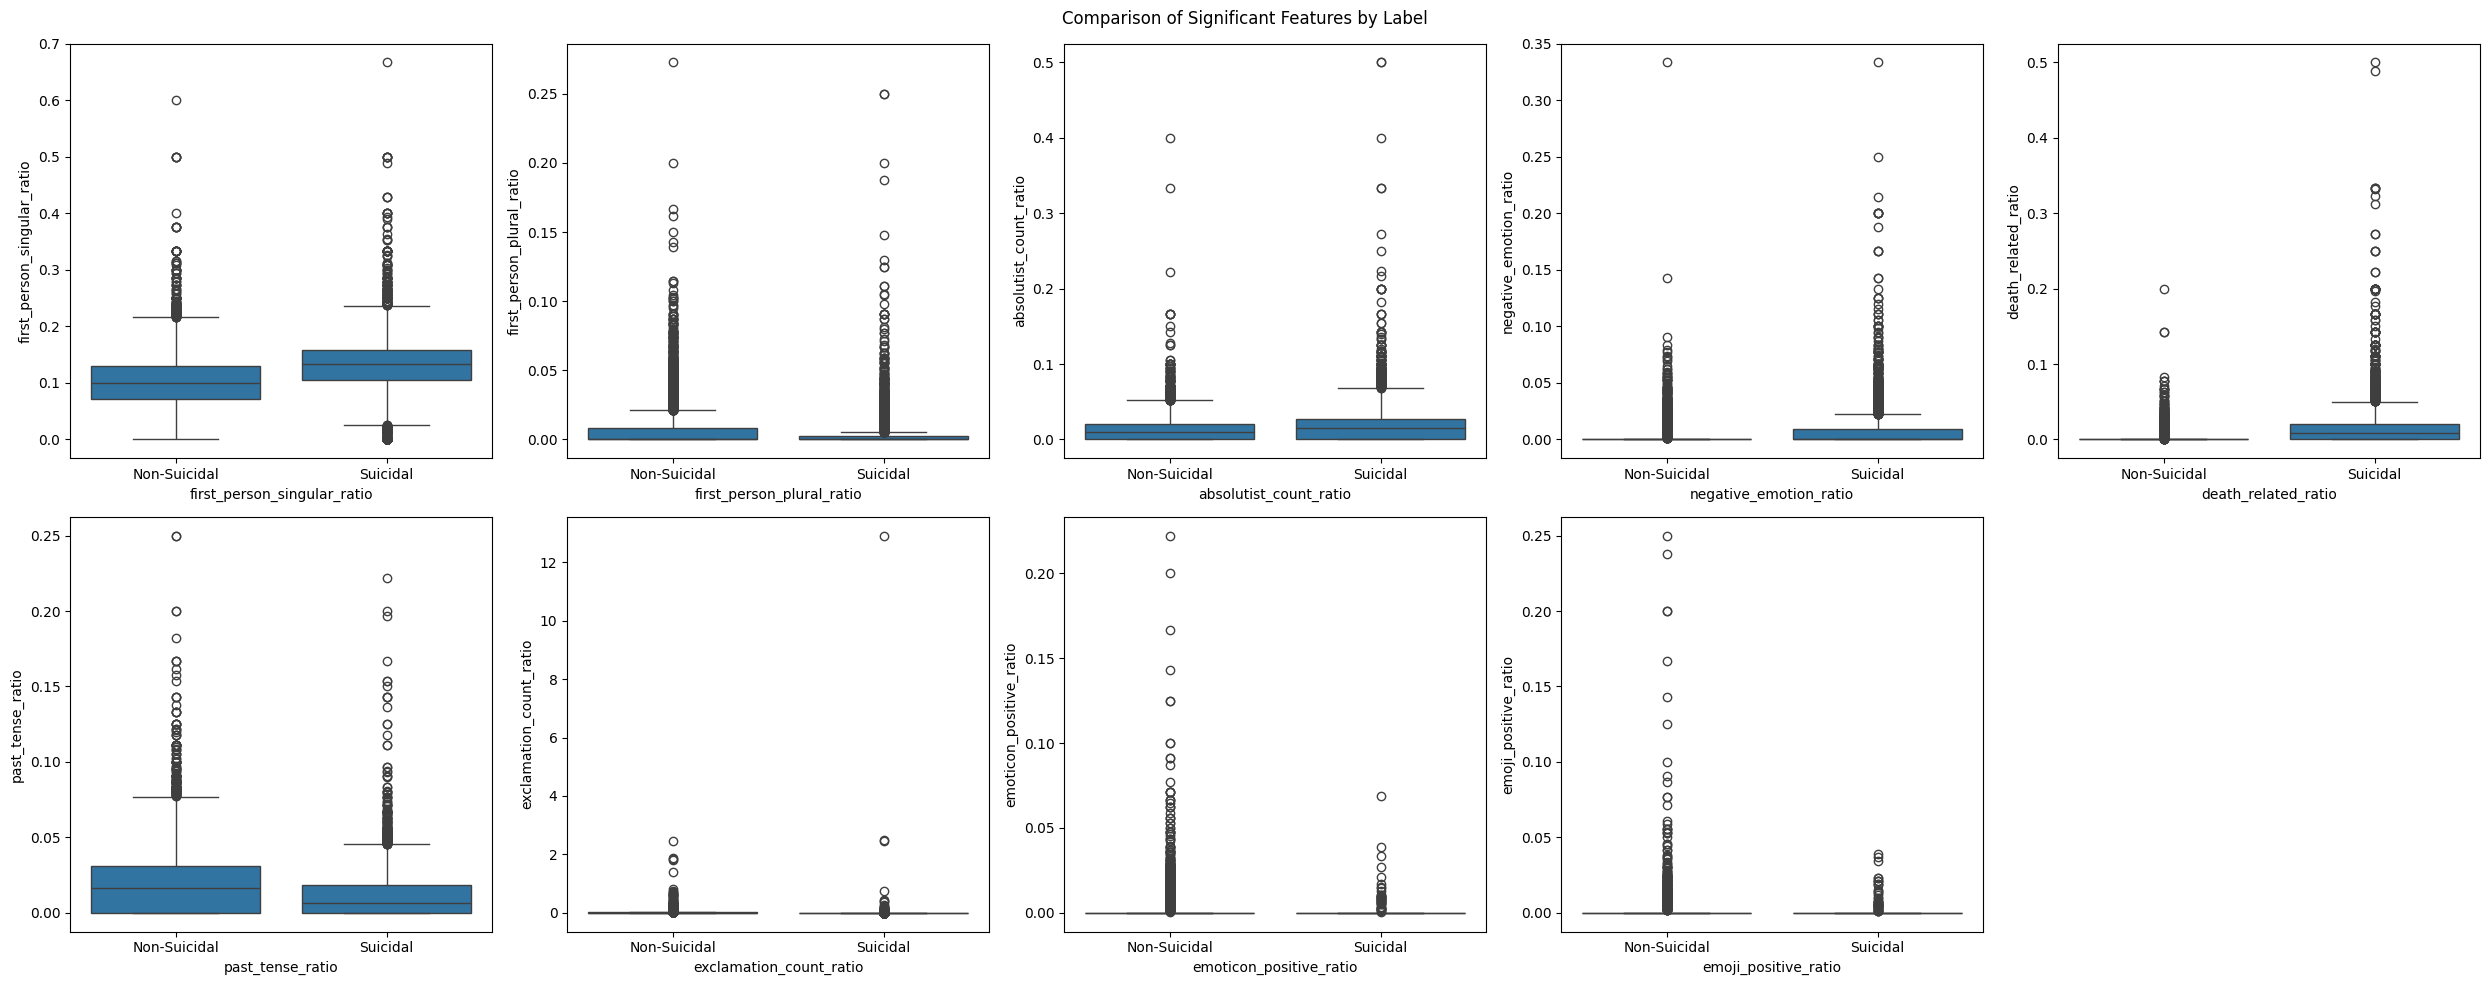

In [ ]:
row = 2
col = int(np.ceil(len(significant_features) / 2))

fig, ax = plt.subplots(row, col, figsize=[25, 10])
ax = ax.flatten()

for i in range(len(significant_features)):
    sns.boxplot(data=significant_subset, x="label", y=significant_features[i], ax=ax[i])
    ax[i].set_xlabel(significant_features[i])

for j in range(len(significant_features), len(ax)):
    fig.delaxes(ax[j])

fig.suptitle('Comparison of Significant Features by Label')
plt.tight_layout()

The box plots confirm the class separation for both features. The distributions are skewed right in both cases, most posts have low values, with a long tail of high-usage posts. This skew is more pronounced for `death_related_ratio`, where the majority of non-suicidal posts cluster near zero while suicidal posts show a much wider spread.

These two features are strong candidates for interpretable baseline modeling. The remaining medium-effect features (past tense, negative emotion, absolutist language, exclamation marks) provide supporting signal and may prove useful in combination, which motivates the next question.

---

### EDA Question 2: Do suicidal posts exhibit distinct combinations of features?

Knowing which individual features differ is a starting point, but classifiers also learn interactions. A post might have moderate first-person usage and moderate absolutist language, neither elevated enough to trigger on their own, but their combined occurrence could still be a reliable suicidal signal. Here we inspect within-class feature correlations to see whether the two classes show structurally different feature co-occurrence patterns.

We compute correlation matrices separately for each class, then compare the strongest co-occurring feature pairs. A meaningful difference in correlation structure between classes would suggest that suicidality is partly encoded in *how features combine*, not just which features are elevated.

In [ ]:
# Use only linguistic and stylistic features — exclude subreddit metadata
linguistic_features = [
    'first_person_singular', 'first_person_plural', 'absolutist_count',
    'negative_emotion', 'death_related', 'past_tense',
    'exclamation_count', 'question_count', 'upper_word_count'
]

linguistic_df = df[linguistic_features + ['label']]

In [ ]:
ratio_correlations_suicidal = linguistic_df[linguistic_df["label"] == "Suicidal"].drop(["label"], axis=1).corr()
ratio_correlations_non_suicidal = linguistic_df[linguistic_df["label"] == "Non-Suicidal"].drop(["label"], axis=1).corr()

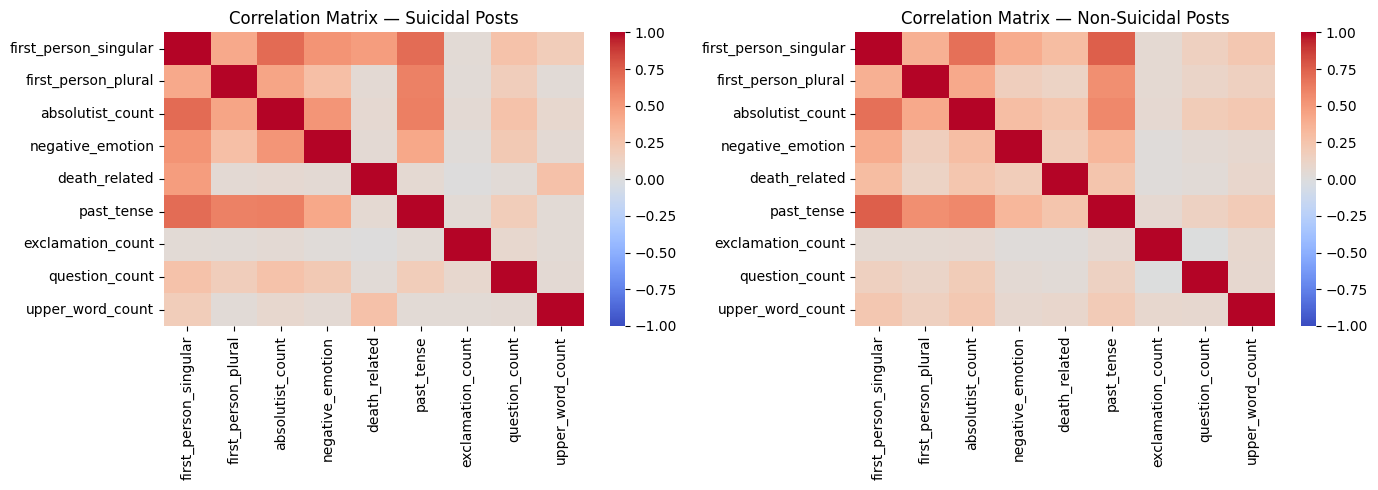

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=[14, 5])
sns.heatmap(ratio_correlations_suicidal, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title("Correlation Matrix — Suicidal Posts")
sns.heatmap(ratio_correlations_non_suicidal, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title("Correlation Matrix — Non-Suicidal Posts")
plt.tight_layout()

In [ ]:
def get_good_correlations(correlation_mat):
    good_ratio_correlations =  correlation_mat.map(lambda x : (x > 0.3 or x < -0.3)) #  0.3 < x < -0.3
    good_ratio_correlations_indices = list(zip(*np.where(good_ratio_correlations)))

    indices = correlation_mat.index
    good_ratio_correlations_vals = []
    index_buffer = [] # list of indices so reverses are not included

    for index in good_ratio_correlations_indices:
        i, j = index

        if i != j:
            row, col = indices[i], indices[j]

            if (col, row) not in index_buffer:
                good_ratio_correlations_vals.append({"key": (row, col), "val": correlation_mat.loc[row, col]})
                index_buffer.append((row, col))

    good_ratio_correlations_vals.sort(key=lambda x: x["val"], reverse=True)

    good_ratio_correlations_vals = pd.DataFrame(good_ratio_correlations_vals)

    return good_ratio_correlations_vals

In [ ]:
print("Top correlated pairs — Suicidal posts")
good_ratio_correlations_suicidal = get_good_correlations(ratio_correlations_suicidal)
good_ratio_correlations_suicidal

Top correlated pairs — Suicidal posts


,key,val
0,"(first_person_singular, absolutist_count)",0.707225
1,"(first_person_singular, past_tense)",0.699225
2,"(absolutist_count, past_tense)",0.620555
3,"(first_person_plural, past_tense)",0.611319
4,"(first_person_singular, negative_emotion)",0.524926
5,"(absolutist_count, negative_emotion)",0.518695
6,"(first_person_singular, death_related)",0.479908
7,"(first_person_plural, absolutist_count)",0.445055
8,"(negative_emotion, past_tense)",0.426242
9,"(first_person_singular, first_person_plural)",0.414896


In [ ]:
print("Top correlated pairs — Non-Suicidal posts")
good_ratio_correlations_non_suicidal = get_good_correlations(ratio_correlations_non_suicidal)
good_ratio_correlations_non_suicidal

Top correlated pairs — Non-Suicidal posts


,key,val
0,"(first_person_singular, past_tense)",0.751211
1,"(first_person_singular, absolutist_count)",0.686360
2,"(absolutist_count, past_tense)",0.583271
3,"(first_person_plural, past_tense)",0.549580
4,"(first_person_plural, absolutist_count)",0.415805
5,"(first_person_singular, negative_emotion)",0.405126
6,"(first_person_singular, first_person_plural)",0.382219
7,"(negative_emotion, past_tense)",0.339296
8,"(first_person_singular, death_related)",0.303966


The top pairs differ between classes in a meaningful way. To visualize this, we plot the strongest class-specific pair for each group, using only posts from that class.

Text(0.5, 1.0, '[SUICIDAL] first_person_singular vs absolutist_count')

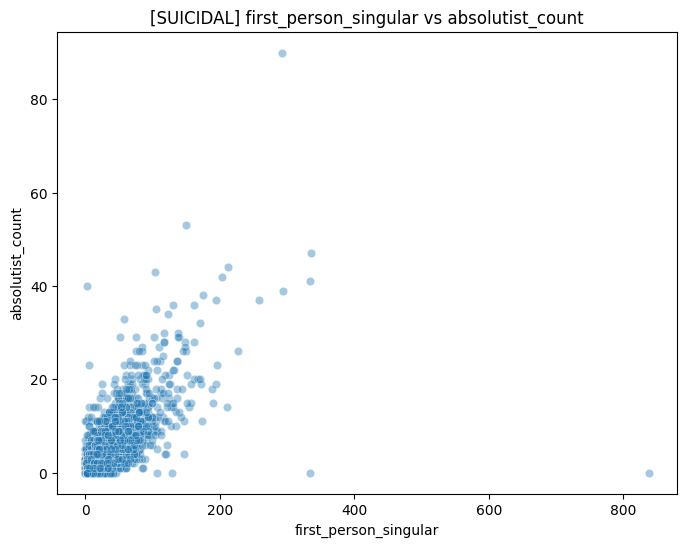

In [ ]:
# Strongest pair in suicidal posts: first_person_singular + absolutist_count
suicidal_only = df[df['label'] == 'Suicidal']
plt.figure(figsize=[8, 6])
sns.scatterplot(data=suicidal_only, x="first_person_singular", y="absolutist_count", alpha=0.4)
plt.title("[SUICIDAL] first_person_singular vs absolutist_count")

Text(0.5, 1.0, '[NON-SUICIDAL] first_person_singular vs past_tense')

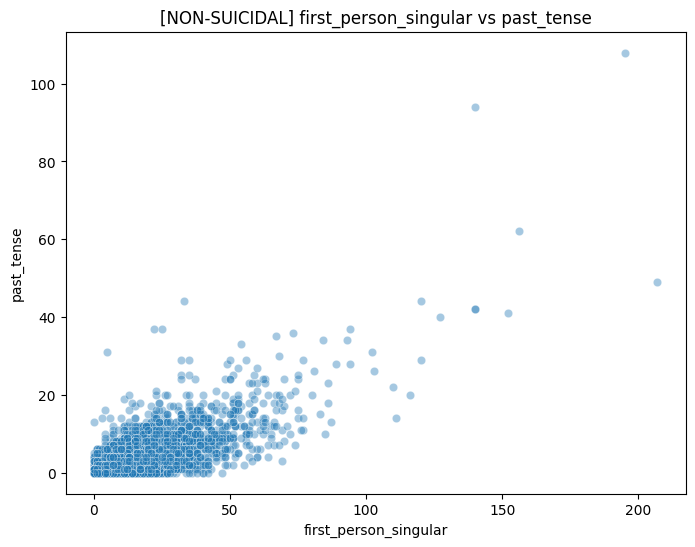

In [ ]:
# Strongest pair in non-suicidal posts: first_person_singular + past_tense
non_suicidal_only = df[df['label'] == 'Non-Suicidal']
plt.figure(figsize=[8, 6])
sns.scatterplot(data=non_suicidal_only, x="first_person_singular", y="past_tense", alpha=0.4)
plt.title("[NON-SUICIDAL] first_person_singular vs past_tense")

The correlation structure tells a coherent story. In **suicidal posts**, first-person singular language co-occurs most strongly with absolutist wording (r = 0.71), the combination of self-focus and radical, all-or-nothing thinking is characteristic of suicidal ideation in posts. In **non-suicidal posts**, first-person singular co-occurs most strongly with past tense (r = 0.75), a pattern consistent with reflective personal storytelling/reminiscing rather than present distress.

This distinction matters for classification: a model that only looks at first-person usage in isolation would miss this structural difference entirely. Models that can capture feature interactions, whether through engineered interaction terms or learned representations, are better to utilize of this pattern for classification.

---

### EDA Question 3: What characteristics appear in distress-only posts and subtle suicidal posts that may cause classification errors?

The two previous questions established what the features can detect. This question focuses on what they *cannot*. Even with strong discriminative features, some posts will be difficult to classify. Examples of these are non-suicidal posts that look linguistically similar to suicidal ones (false positive risk) and suicidal posts that avoid the expected markers entirely (false negative risk).

Understanding these failure modes define the performance ceiling for any lexical model and motivate the need for context-sensitive representations.

We define two ambiguous subgroups and compare their feature profiles against their respective class averages. This lets us see not just *which posts* are ambiguous, but *which features* help or fail on each type.

In [ ]:
ratio_columns = list(df.loc[:, "first_person_singular_ratio":].columns)

In [ ]:
q75_by_class = df.groupby("label")[ratio_columns].quantile(0.75)
q75_by_class

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,question_count_ratio,upper_word_count_ratio,emoticon_positive_ratio,emoticon_negative_ratio,emoticon_crying_ratio,emoticon_neutral_ratio,emoticon_heart_ratio,emoticon_broken_heart_ratio,emoji_negative_ratio,emoji_positive_ratio,emoji_crisis_ratio,emoji_implicit_distress_ratio
label,,,,,,,,,,,,,,,,,,,
Non-Suicidal,0.129630,0.008403,0.021008,0.000000,0.00,0.030769,0.014706,0.003236,0.005882,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Suicidal,0.157895,0.002204,0.027322,0.009009,0.02,0.018182,0.000000,0.004237,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
q25_by_class = df.groupby("label")[ratio_columns].quantile(0.25)
q25_by_class

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,question_count_ratio,upper_word_count_ratio,emoticon_positive_ratio,emoticon_negative_ratio,emoticon_crying_ratio,emoticon_neutral_ratio,emoticon_heart_ratio,emoticon_broken_heart_ratio,emoji_negative_ratio,emoji_positive_ratio,emoji_crisis_ratio,emoji_implicit_distress_ratio
label,,,,,,,,,,,,,,,,,,,
Non-Suicidal,0.071429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Suicidal,0.104961,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Two sparsity findings are worth noting before defining the groups:
- The 75th percentile of `negative_emotion_ratio` for non-suicidal posts is **0** — meaning at least 75% of non-suicidal posts contain no negative emotion tokens at all.
- The 25th percentile of `death_related_ratio` for suicidal posts is also **0** — meaning at least 25% of suicidal posts contain no death-related terms.

The second finding suggests that even the strongest lexical feature (Cohen's d = 0.76) scores zero for a quarter of suicidal posts. This establishes a baseline on any purely keyword-based model's recall.

In [ ]:
# Ambiguous non-suicidal: high negative emotion but no death-related terms
pd.set_option('display.max_colwidth', None)
ns_q75_neg = q75_by_class.loc['Non-Suicidal', 'negative_emotion_ratio']

ambiguous_nonsuicidal = df[
    (df['label'] == 'Non-Suicidal') &
    (df['negative_emotion_ratio'] >= ns_q75_neg) &
    (df['death_related_ratio'] == 0)
]

print("Ambiguous Non-Suicidal Posts")
print(f"Defined as: negative_emotion_ratio >= {ns_q75_neg} (75th pct) AND death_related_ratio == 0")
print(f"Group size: {len(ambiguous_nonsuicidal)} posts")
display(ambiguous_nonsuicidal["text_cleaned"].sample(10, random_state=random_seed))

Ambiguous Non-Suicidal Posts
Defined as: negative_emotion_ratio >= 0.0 (75th pct) AND death_related_ratio == 0
Group size: 7209 posts


363                      I just got my dream job!!!!! I am so excited and I just want to share with anyone and everyone. I just got my dream job!!!! It’s something I don’t have much experience with, so I’m nervous, but so happy. Not totally sure about the start date yet, but soon. I’m going to be an organizer for my state’s public education union. Anyone with labor organizing experience, any tips? This will improve so many things in my life. Literally double my current salary. I will never again have to see a certain coworker who is one of the worst human beings I have ever met. It will be wonderful experience for my future career goals. I’ll get to use what I’m learning in grad school. I will have a little more flexibility in my schedule. More time off. I’ll actually be treated like a responsible professional adult. I’ll be a part of an effective union!
445                                                                                                                                  

In [ ]:
# Subtle suicidal: suicidal posts with no death-related terms (bottom 25%)
pd.set_option('display.max_colwidth', None)
s_q25_death = df[df['label'] == 'Suicidal']['death_related_ratio'].quantile(0.25)

subtle_suicidal = df[
    (df['label'] == 'Suicidal') &
    (df['death_related_ratio'] <= s_q25_death)
]

print("Subtle Suicidal Posts")
print(f"Defined as: death_related_ratio <= {s_q25_death} (25th pct within suicidal class)")
print(f"Group size: {len(subtle_suicidal)} posts")
display(subtle_suicidal["text_cleaned"].sample(10, random_state=random_seed))

Subtle Suicidal Posts
Defined as: death_related_ratio <= 0.0 (25th pct within suicidal class)
Group size: 2286 posts


13087                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Now we compare the feature profiles of these ambiguous groups against their class averages to see which features compensate and which ones fail.

In [ ]:
# Focus on the most interpretable features for the profile comparison
profile_features = [
    'first_person_singular_ratio', 'first_person_plural_ratio',
    'absolutist_count_ratio', 'negative_emotion_ratio',
    'death_related_ratio', 'past_tense_ratio',
    'exclamation_count_ratio', 'question_count_ratio'
]

profile_comparison = pd.DataFrame({
    'All Non-Suicidal': df[df['label']=='Non-Suicidal'][profile_features].mean(),
    'Ambiguous Non-Suicidal': ambiguous_nonsuicidal[profile_features].mean(),
    'All Suicidal': df[df['label']=='Suicidal'][profile_features].mean(),
    'Subtle Suicidal': subtle_suicidal[profile_features].mean(),
})

profile_comparison.round(4)

,All Non-Suicidal,Ambiguous Non-Suicidal,All Suicidal,Subtle Suicidal
first_person_singular_ratio,0.1029,0.1030,0.1315,0.1291
first_person_plural_ratio,0.0066,0.0066,0.0032,0.0031
absolutist_count_ratio,0.0136,0.0136,0.0195,0.0207
negative_emotion_ratio,0.0019,0.0019,0.0068,0.0078
death_related_ratio,0.0014,0.0000,0.0156,0.0000
past_tense_ratio,0.0198,0.0195,0.0112,0.0096
exclamation_count_ratio,0.0165,0.0173,0.0038,0.0099
question_count_ratio,0.0050,0.0052,0.0062,0.0081


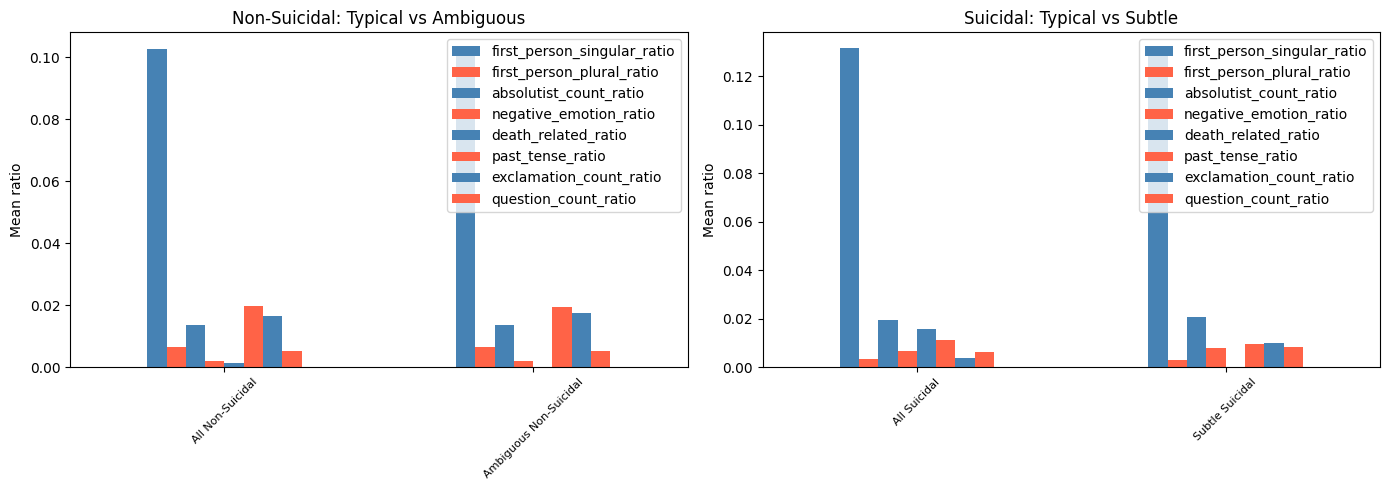

In [ ]:
# Visualize the profile comparison
fig, axes = plt.subplots(1, 2, figsize=[14, 5])

profile_comparison[['All Non-Suicidal', 'Ambiguous Non-Suicidal']].T.plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], rot=45
)
axes[0].set_title('Non-Suicidal: Typical vs Ambiguous')
axes[0].set_ylabel('Mean ratio')
axes[0].tick_params(axis='x', labelsize=8)

profile_comparison[['All Suicidal', 'Subtle Suicidal']].T.plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], rot=45
)
axes[1].set_title('Suicidal: Typical vs Subtle')
axes[1].set_ylabel('Mean ratio')
axes[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()

The profile comparison reveals different failure modes for each group.

**Ambiguous Non-Suicidal posts** are elevated on negative emotion by definition, but the profile shows they also tend to have higher exclamation mark and question mark usage than typical non-suicidal posts. These are stylistic markers of outward expression (i.e., venting, seeking advice and sharing frustration) that help distinguish them from suicidal writing even when emotional language is high. A classifier with exclamation and question features would have some signal to work with.

**Subtle Suicidal posts** are more difficult. By definition they score zero on `death_related_ratio`, but notably, other features do not compensate, the profile is nearly flat compared to typical suicidal posts across all remaining features. `first_person_singular_ratio` stays comparable, and absolutist and negative emotion  language show only marginal differences. These posts are not detectable through any  alternative lexical signal; the suicidality is carried entirely by meaning and context  rather than vocabulary. Their ideation is expressed through:

- Euphemistic framing: *"give up", "not be around", "vacation from everything"*
- Implicit planning without explicit death words: specific dosage or method references that bypass the death-related lexicon
- Short, resigned statements that are lexically weak but contextually unambiguous
- Abstract or dissociative language: *"catatonic state of unbeing", "I no longer have this border"*

These cases represent a hard limit for purely lexical approaches. No amount of feature engineering can recover suicidal intent that is deliberately or unconsciously expressed without suicidal vocabulary.

This finding directly motivates the use of context-sensitive representations in the classification stage. A bag-of-words or TF-IDF model operates on token presence and frequency, it cannot distinguish *"I just want to give up"* (suicidal resignation) from *"I give up trying to fix this bug"* (casual frustration) without the surrounding context that makes the meaning unambiguous. However, they do serve as a good baseline for comparison.

---

### **EDA Conclusion**

The analysis converges on a consistent pattern: suicidality leaves traces in language, but those traces are neither uniform nor sufficient on their own.

**What the features reveal:**

Death-related language is the single strongest discriminative signal (Cohen's d = 0.76), followed by first-person singular pronoun usage (d = 0.56). Together, these two features reflect a pattern of self-focused narration oriented explicitly toward mortality, a combination that is relatively rare in non-suicidal posts. Several medium-effect features add supporting signal: past-tense narration and exclamation marks are both more common in non-suicidal posts, reflecting a reflective, outward-expressive register that differs from the quieter internal tone of suicidal writing.

**What the interactions reveal:**

Suicidal posts show a tighter dependency between first-person singular and absolutist language (r = 0.71) compared to non-suicidal posts, where first-person singular couples more strongly with past tense (r = 0.75). This structural difference suggests that suicidality is partly encoded in *how features co-occur*, not only which features are elevated. Models that can learn feature interactions are better equipped to exploit this.

**What the ambiguous cases reveal:**

At least 25% of suicidal posts contain zero death-related terms, the strongest lexical feature scores zero for a substantial fraction of the positive class. These subtle cases express ideation through euphemism, implicit planning, resignation, and dissociative language that no keyword list can reliably capture. This sets a performance ceiling for any purely keyword-based model and identifies the specific failure mode that context-sensitive representations are designed to address.

**Implications for the classification stage:**
- Start with interpretable baselines (logistic regression on normalized ratio features) to establish a lexical performance ceiling.
- Evaluate model errors specifically on the ambiguous subsets identified here, false positive risk from high-distress non-suicidal posts, and false negative risk from subtle suicidal posts with no death-related terms.
- Use context-sensitive representations (e.g., fine-tuned transformer embeddings) to target the subtle suicidal cases that lexical models are structurally unable to handle.

---

## **Classification**

In [ ]:
df = pd.read_csv("suicidality_dataset_w_features.csv", keep_default_na=False, index_col=0)
df.head()

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count,...,emoticon_positive,emoticon_negative,emoticon_crying,emoticon_neutral,emoticon_heart,emoticon_broken_heart,emoji_negative,emoji_positive,emoji_crisis,emoji_implicit_distress
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(df["label"])
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
mapping_inv = {v: k for k, v in mapping.items()}

print("Label Mapping:", mapping)

Label Mapping: {'Non-Suicidal': np.int64(0), 'Suicidal': np.int64(1)}


A standard 80/20 split is applied to separate the test set. The training portion is further split 80/20 to create a validation set for models that require it (neural network, fine-tuned BERT). Stratified splitting is used throughout to preserve the original class distribution across all three sets.

Traditional models (KNN, Logistic Regression, Naive Bayes) use only train and test; the validation set is used for tuning neural network hyperparameters and BERT fine-tuning.

In [ ]:
X_all = df.drop(["label"], axis=1)
y_all = label_encoder.transform(df["label"])
y_all = pd.Series(y_all, index=df.index)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=random_seed, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=random_seed, stratify=y_trainval
)

print(f"Train:      {len(y_train):,} | {dict(pd.Series(y_train).value_counts())}")
print(f"Validation: {len(y_val):,} | {dict(pd.Series(y_val).value_counts())}")
print(f"Test:       {len(y_test):,} | {dict(pd.Series(y_test).value_counts())}")

Train:      9,904 | {0: np.int64(5248), 1: np.int64(4656)}
Validation: 2,476 | {0: np.int64(1312), 1: np.int64(1164)}
Test:       3,096 | {0: np.int64(1641), 1: np.int64(1455)}


In [ ]:
baseline_accuracy = pd.Series(y_all).value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline_accuracy*100:.2f}%")
print("All models must exceed this to demonstrate learning.")

Majority-class baseline accuracy: 52.99%
All models must exceed this to demonstrate learning.


---

## **Part 1: Traditional Machine Learning Models**

This part covers three traditional machine learning models: K-Nearest Neighbors, Logistic Regression, and Multinomial Naive Bayes. All three operate on TF-IDF or count-based text representations combined with engineered linguistic features processed through a shared preprocessing pipeline.

These models serve as interpretable baselines that establish a performance ceiling for purely lexical approaches. Their error analysis directly motivates the transition to context-sensitive deep learning models in Part 2.

### **Preprocessing**

For traditional models, `text_cleaned` is lowercased to reduce vocabulary noise. The uppercase feature is already captured in the engineered features, so no discriminative information is lost.

The `FeatureTransformer` applies TF-IDF vectorization to the text column and combines it with the normalized engineered features into a single feature matrix. It is fitted on `X_trainval`, the full 80% training pool, so the vocabulary and feature statistics are derived from as much data as possible before cross-validation splits it internally.

In [ ]:
X_trainval_trad = X_trainval.copy()
X_test_trad     = X_test.copy()

X_trainval_trad["text_traditional"] = X_trainval_trad["text_cleaned"].str.lower()
X_test_trad["text_traditional"]     = X_test_trad["text_cleaned"].str.lower()

drop_cols = ["title", "post", "text", "text_cleaned"]
X_trainval_trad = X_trainval_trad.drop(columns=drop_cols)
X_test_trad     = X_test_trad.drop(columns=drop_cols)

transformer = FeatureTransformer(text_col="text_traditional")
transformer.fit(X_trainval_trad)

X_trainval_transformed = transformer.transform(X_trainval_trad)
X_test_transformed     = transformer.transform(X_test_trad)

print(f"Transformed feature matrix — trainval: {X_trainval_transformed.shape} | test: {X_test_transformed.shape}")

Transformed feature matrix — trainval: (12380, 10025) | test: (3096, 10025)


---

### **K-Nearest Neighbors (KNN)**

#### **Overview**

This section develops a K-Nearest Neighbors (KNN) classifier for suicidality detection from Reddit posts. KNN classifies each post by finding the *k* most similar posts in the training set and taking a majority vote. Hyperparameter tuning is conducted over the number of neighbors, weighting scheme, and distance metric using 5-fold cross-validation.

#### **Justification**

KNN is included as a non-parametric, similarity-based baseline. It makes no assumptions about the data distribution, relying instead on direct comparison with training instances. In TF-IDF space, this translates to a concrete question: does this post look linguistically similar to posts we already know are suicidal?

Cosine distance is included in the tuning grid as it is more appropriate than Euclidean distance for high-dimensional sparse vectors, it measures directional similarity regardless of post length, so two posts using the same vocabulary proportionally are treated as similar even if one is much longer. Distance-weighted voting is also included to give closer neighbors more influence over the prediction.

KNN is expected to underperform parametric classifiers in this setting due to the curse of dimensionality, but it provides a useful reference for what a purely instance-based approach can achieve without learning an explicit decision boundary. The dataset's mild class imbalance, approximately 47% suicidal vs. 53% non-suicidal, does not pose a significant problem for this approach.

#### **Baseline Model**

Before tuning, we evaluate default KNN on `X_trainval_transformed` to confirm the model learns meaningful signal above the majority-class baseline.

In [ ]:
knn_baseline = KNeighborsClassifier()
knn_baseline.fit(X_trainval_transformed, y_trainval)

print(f"KNN baseline accuracy: {knn_baseline.score(X_trainval_transformed, y_trainval)*100:.2f}%")
print(classification_report(y_trainval, knn_baseline.predict(X_trainval_transformed), target_names=label_encoder.classes_))

KNN baseline accuracy: 88.83%
              precision    recall  f1-score   support

Non-Suicidal       0.90      0.89      0.89      6560
    Suicidal       0.87      0.89      0.88      5820

    accuracy                           0.89     12380
   macro avg       0.89      0.89      0.89     12380
weighted avg       0.89      0.89      0.89     12380



#### **Hyperparameter Tuning**

GridSearchCV is run on `X_trainval_transformed` with 5-fold cross-validation. Passing the full 80% pool here means each fold trains on ~64% of the total dataset, the same proportion that would be used if we had split train and validation separately. Scoring is done on F1 to reflect the class of interest.

In [ ]:
param_grid_knn = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "cosine"]
}

knn_cv = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)
knn_cv.fit(X_trainval_transformed, y_trainval)

print("Best params:", knn_cv.best_params_)
print("Best CV F1: ", knn_cv.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Best CV F1:  0.8266148386647341


#### Optimized Model

In [ ]:
optimized_knn = KNeighborsClassifier(**knn_cv.best_params_)
optimized_knn.fit(X_trainval_transformed, y_trainval)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Evaluation on the Test Set

In [ ]:
knn_preds = optimized_knn.predict(X_test_transformed)

print(f"KNN test accuracy: {accuracy_score(y_test, knn_preds)*100:.2f}%")
print(classification_report(y_test, knn_preds, target_names=label_encoder.classes_, digits=4))

KNN test accuracy: 84.53%
              precision    recall  f1-score   support

Non-Suicidal     0.8645    0.8397    0.8519      1641
    Suicidal     0.8249    0.8515    0.8380      1455

    accuracy                         0.8453      3096
   macro avg     0.8447    0.8456    0.8450      3096
weighted avg     0.8459    0.8453    0.8454      3096



#### Error Analysis

In [ ]:
knn_error_bool = knn_preds != y_test.values
knn_errors = pd.concat([
    X_test[knn_error_bool].reset_index(drop=True),
    pd.Series(y_test.values[knn_error_bool], name="true_label").map(mapping_inv)
], axis=1)

print(f"Total KNN errors: {knn_error_bool.sum()} ({knn_error_bool.mean()*100:.1f}% of test set)")
print(knn_errors["true_label"].value_counts())

Total KNN errors: 479 (15.5% of test set)
true_label
Non-Suicidal    263
Suicidal        216
Name: count, dtype: int64


In [ ]:
suicidal_knn_errors = (
    knn_errors[knn_errors["true_label"] == "Suicidal"]["text_cleaned"]
    .sample(5, random_state=random_seed)
    .reset_index(drop=True)
)
print("Sample false negatives — suicidal posts missed by KNN:")
for i, text in enumerate(suicidal_knn_errors):
    print(f"\n{i+1}. {textwrap.fill(text, width=120)}")

Sample false negatives — suicidal posts missed by KNN:

1. Sick of it all For the whole day, I've been trying to make other people feel better whenever I could. I tried to
empathize, my god, I've tried...Even tho I don't have the energy. Another night, a long, long night since I have
insomnia. I've been watching alprazolam on my desk, and decided to take it all. I didn't take even half of it and I'm
feeling symptoms kicking in. I'm gonna take it all and mix it with some other drugs and alcohol and be done with it. I
hope the end is near. It's been a pleasure. &#x200B; EDIT: If anyone is interested, I am still here but I've got planty
of pills to swallow. Well, there is no need to rush. Right now I feel good actually. My anxieties are being suppressed
by meds and it's like a freedom I am so desperate for.

2. I'm sick of waking up every morning It's hard to wake up, impossible to get a decent sleep by not being annoyed by my
thoughts. Since quite a while my life is like this, it has bec

In [ ]:
nonsuicidal_knn_errors = (
    knn_errors[knn_errors["true_label"] == "Non-Suicidal"]["text_cleaned"]
    .sample(5, random_state=random_seed)
    .reset_index(drop=True)
)
print("Sample false positives — non-suicidal posts flagged by KNN:")
for i, text in enumerate(nonsuicidal_knn_errors):
    print(f"\n{i+1}. {textwrap.fill(text, width=120)}")

Sample false positives — non-suicidal posts flagged by KNN:

1. My grandma passed away last night It’s not sad at all. It’s a huge relief. She was ready for it and has been saying she
was ready for it for years. Her husband passed years ago and ever since she has just been alive and not really living.
We didn’t know she was sick until a few months ago. She was fine and then all of a sudden had really bad pain in her
leg. They did a scan and she had cancer throughout her entire body. Small cell. They gave her 6 months. She lasted 3. I
visited her a month ago and she seemed okay still. She never seemed to be in too much pain until a couple of days ago
because she couldn’t swallow any longer so her extra pain meds weren’t helping, the morphine can be absorbed through the
mouth, not just by swallowing, but the oxy could not. They gave her fentanyl patches but said it could take a couple of
days to kick in. She didn’t seem in pain yesterday though. Maybe it was because she knew it was time.

From these error samples, two failure modes emerge. False negatives tend to be posts where suicidal intent is expressed indirectly, without the explicit death-related vocabulary that most neighboring training instances carry. False positives tend to be emotionally intense non-suicidal posts whose word distributions land close in TF-IDF space to genuinely suicidal posts. Both failure modes are consistent with the curse of dimensionality: in very high-dimensional space, distance metrics become less discriminative and nearest neighbors less representative.

---

### **Logistic Regression**

#### **Overview**

This section develops a Logistic Regression classifier for suicidality detection from Reddit posts. Logistic Regression fits a linear decision boundary in the combined TF-IDF and engineered feature space. Hyperparameter tuning is conducted over regularization type (L1 and L2) and regularization strength (C) using 5-fold cross-validation.

#### **Justification**

Logistic Regression is the canonical baseline for text classification and is a well-motivated choice here. TF-IDF representations are high-dimensional and sparse, and Logistic Regression handles this efficiently through regularization. Its coefficients are directly interpretable, the sign and magnitude of each feature weight indicates how strongly it pushes a prediction toward or away from the Suicidal class, which is especially useful in a sensitive mental health context where model behavior should be auditable.

L1 and L2 regularization are both included as tuning candidates. L1 induces sparsity by zeroing out uninformative features, producing a leaner model that relies on a smaller subset of the vocabulary. L2 penalizes large coefficients uniformly, tending to distribute weight more evenly across correlated features. The `saga` solver is used as it supports both penalty types efficiently on large sparse datasets.

While Logistic Regression cannot capture feature interactions or contextual meaning, it represents the strongest achievable performance from a linear model on this feature set — making it the most meaningful point of comparison for the deep learning approaches that follow.

In [ ]:
logreg_baseline = LogisticRegression(max_iter=1000, random_state=random_seed)
logreg_baseline.fit(X_trainval_transformed, y_trainval)

print(f"LogReg baseline accuracy: {logreg_baseline.score(X_trainval_transformed, y_trainval)*100:.2f}%")
print(classification_report(y_trainval, logreg_baseline.predict(X_trainval_transformed), target_names=label_encoder.classes_))

LogReg baseline accuracy: 96.27%
              precision    recall  f1-score   support

Non-Suicidal       0.95      0.98      0.97      6560
    Suicidal       0.97      0.95      0.96      5820

    accuracy                           0.96     12380
   macro avg       0.96      0.96      0.96     12380
weighted avg       0.96      0.96      0.96     12380



#### **Hyperparameter Tuning**

We tune the regularization type (L1/L2) and strength (C) using 5-fold GridSearchCV on `X_trainval_transformed`. L1 induces sparsity by zeroing out uninformative TF-IDF features, while L2 penalizes large coefficients uniformly. The `saga` solver supports both penalty types efficiently on large sparse datasets. Scoring uses F1 on the Suicidal class.

In [ ]:
param_grid_logreg = {
    "penalty": ["l1", "l2"],
    "C": np.logspace(-3, 3, 6)
}

logreg_cv = GridSearchCV(
    LogisticRegression(solver="saga", max_iter=1000, random_state=random_seed),
    param_grid=param_grid_logreg,
    cv=5,
    scoring="f1",
    n_jobs=2,
    return_train_score=True,
    verbose=1
)
logreg_cv.fit(X_trainval_transformed, y_trainval)

print("Best params:", logreg_cv.best_params_)
print("Best CV F1: ", logreg_cv.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\Ezra\OneDrive - De La Salle University - Manila\Documents\DLSU\3rd_Year\Term_2\STINTSY\Notebooks\stintsy\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Ezra\OneDrive - De La Salle University - Manila\Documents\DLSU\3rd_Year\Term_2\STINTSY\Notebooks\stintsy\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [ ]:
cv_results = pd.DataFrame(logreg_cv.cv_results_)

fig, ax = plt.subplots(figsize=[10, 5])
ax.plot(cv_results["mean_train_score"], label="Train")
ax.plot(cv_results["mean_test_score"],  label="Validation")
ax.set_title("Logistic Regression — Train and Validation F1 Across Configurations")
ax.set_xlabel("Configuration")
ax.set_ylabel("F1 Score")
ax.legend()
plt.tight_layout()
plt.show()

#### Optimized Model

In [ ]:
best_C = logreg_cv.best_params_["C"]
best_penalty = logreg_cv.best_params_["penalty"]

optimized_logreg = LogisticRegression(
    max_iter=1000, random_state=random_seed,
    C=best_C, penalty=best_penalty, solver="saga"
)
optimized_logreg.fit(X_trainval_transformed, y_trainval)

#### Evaluation on the Test Set

In [ ]:
logreg_preds = optimized_logreg.predict(X_test_transformed)

print(f"LogReg test accuracy: {accuracy_score(y_test, logreg_preds)*100:.2f}%")
print(classification_report(y_test, logreg_preds, target_names=label_encoder.classes_, digits=4))

In [ ]:
joblib.dump(optimized_logreg, "optimized_logreg.joblib")

#### Error Analysis

In [ ]:
logreg_error_bool = logreg_preds != y_test.values
logreg_errors = pd.concat([
    X_test[logreg_error_bool].reset_index(drop=True),
    pd.Series(y_test.values[logreg_error_bool], name="true_label").map(mapping_inv)
], axis=1)

print(f"Total LogReg errors: {logreg_error_bool.sum()} ({logreg_error_bool.mean()*100:.1f}% of test set)")
print(logreg_errors["true_label"].value_counts())

In [ ]:
suicidal_logreg_errors = (
    logreg_errors[logreg_errors["true_label"] == "Suicidal"]["text_traditional"]
    .sample(10, random_state=random_seed)
    .reset_index(drop=True)
)
print("Sample false negatives — suicidal posts missed by LogReg:")
for i, text in enumerate(suicidal_logreg_errors):
    print(f"\n{i+1}. {textwrap.fill(text, width=120)}")

A recurring pattern in false negatives is context-dependent suicidality. These are posts where individual words appear neutral or even positive, but the overall meaning signals distress. Sarcasm and irony are particularly problematic: a post using positive emojis while expressing hopelessness appears non-suicidal to a TF-IDF model because the keywords contradicts the intent. This is the fundamental limitation of bag-of-words approaches.

In [ ]:
nonsuicidal_logreg_errors = (
    logreg_errors[logreg_errors["true_label"] == "Non-Suicidal"]["text_traditional"]
    .sample(10, random_state=random_seed)
    .reset_index(drop=True)
)
print("Sample false positives — non-suicidal posts flagged by LogReg:")
for i, text in enumerate(nonsuicidal_logreg_errors):
    print(f"\n{i+1}. {textwrap.fill(text, width=120)}")

Two patterns appear in false positives. First, non-suicidal posts with high concentrations of negative vocabulary get incorrectly flagged because TF-IDF cannot distinguish their context from genuinely suicidal posts. Second, some posts appear to be mislabeled in the dataset itself, posts expressing genuine distress that were collected from non-suicidal subreddits. This is an inherent limitation of source-based labeling: the subreddit of origin does not guarantee the intent of every individual post.

---

### **Multinomial Naive Bayes**

#### **Overview**

This section develops a Multinomial Naive Bayes (MultinomialNB) model for suicidality classification and prediction from Reddit posts. Beyond a single model, an ablation test is conducted to evaluate and assess the contribution of two independent variables: vectorizer type (TF-IDF vs. CountVectorizer) and n-gram range (unigrams only vs. unigrams and bigrams). These factors yield four model configurations that are systematically trained, tuned, and evaluated against each other.

For this approach, only `text_cleaned` is used as the sole basis for suicidality prediction. This is the cleaned and combined title and post content. As the primary and most information-rich feature, it represents *what* was written, and this type of feature is exactly what MultinomialNB was designed for.

> `title`, `post`, and `text` are excluded as they are already represented by `text_cleaned`.

Engineered features are not included in this approach. While the majority of these features are discrete and count-based, they are derived aggregates that do not represent tokens from the same vocabulary space as the vectorized text features. Their inclusion may also strengthen violations of the independence assumption. Furthermore, combining these features with high-dimensional text representations can introduce inconsistencies in feature interpretation and contribution. Rather than accepting these theoretical and methodological complications, this approach adopts a text-only representation to remain fully aligned with the assumptions of the Multinomial Distribution, ensuring a cleaner and more interpretable model.

The target feature is `label`, which is the suicidality label for each post: `Suicidal` (1) or `Non-Suicidal` (0).

#### **Justification**

Suicidality prediction is fundamentally a text classification problem, making MultinomialNB a natural and well-motivated choice. It is well-established in NLP tasks such as sentiment analysis, spam detection, and mental health text classification. It is specifically designed for discrete, frequency-based features like word counts and TF-IDF weights, directly matching our primary feature representation. It also handles high-dimensional sparse text data efficiently and produces probabilistic predictions that are interpretable, which is especially valuable in a sensitive mental health context.

While Naive Bayes assumes conditional independence between features, which does not strictly hold for text, this assumption is acceptable in practice since the direction of each feature's contribution matters more than modeling exact word dependencies. Finally, with only around a 1,000 instance difference out of around 15,000 total, the mild class imbalance does not pose a problem for this approach.

In [ ]:
# Text-only features for NB (lowercased)
X_text_train    = X_train["text_cleaned"].str.lower()
X_text_val      = X_val["text_cleaned"].str.lower()
X_text_test     = X_test["text_cleaned"].str.lower()
X_text_trainval = X_trainval["text_cleaned"].str.lower()

#### **Vectorization**

For this approach, the text feature is vectorized using either TF-IDF or CountVectorizer depending on the model configuration. A part of the ablation test aims to evaluate and assess whether the choice of vectorizer is significant in producing better representations for suicidality prediction. Both TF-IDF and count-based features are a natural fit for MultinomialNB.

Both vectorizers are initialized with shared base settings so that the only difference between model configurations is the vectorizer type and n-gram range. These settings are standard in text classification tasks that work well in practice.

**Shared Settings:**
- `min_df=3` — ignore tokens appearing in fewer than 3 documents to reduce possible noise
- `max_features=20000` — limit vocabulary to 20,000 most frequent tokens
- `analyzer="word"` — tokenize by word as standard practice
- `stop_words="english"` — remove stop words to reduce noise

**Ablation Variables:**
- `vectorizer_type` ∈ {`tfidf`, `count`} — weighting scheme
- `ngram_range` ∈ {`(1,1)`, `(1,2)`} — unigrams only vs. unigrams and bigrams

Bigrams are included as a candidate because multi-word phrases may carry meaning that individual words alone would miss. The ablation will tell us empirically whether they add meaningful signal.

In [ ]:
vectorizer_shared_parameters = dict(
    min_df=3,
    max_features=20000,
    analyzer="word",
    stop_words="english",
)

vectorizer_types = ["tfidf", "count"]
ngram_ranges = [(1, 1), (1, 2)]
nb_configurations = list(product(vectorizer_types, ngram_ranges))

print("Naive Bayes Configurations:")
for i, (vec_type, ngram) in enumerate(nb_configurations):
    print(f"  Config {i+1}: {vec_type.upper()} | ngram_range={ngram}")

In [ ]:
vectorized_data = {}

for vec_type, ngram in nb_configurations:
    name = f"{'TF-IDF' if vec_type == 'tfidf' else 'Count'} | ngram={ngram}"
    params = {**vectorizer_shared_parameters, "ngram_range": ngram}
    vectorizer = TfidfVectorizer(**params) if vec_type == "tfidf" else CountVectorizer(**params)

    X_train_vec = vectorizer.fit_transform(X_text_train)
    vectorized_data[name] = {
        "vectorizer": vectorizer,
        "X_train": X_train_vec,
        "X_val":   vectorizer.transform(X_text_val),
        "X_test":  vectorizer.transform(X_text_test),
    }
    print(f"{name}: vocab={len(vectorizer.get_feature_names_out()):,} | train shape={X_train_vec.shape}")

From these results, the resulting matrices are highly sparse. Most values are zero since any single post contains only a small fraction of the full vocabulary. This is standard in text classification given the large and varied vocabulary across all documents.

The values in each matrix represent different things: the TF-IDF matrix reflects how significant a token is within a specific post relative to the entire corpus, while the Count matrix reflects how frequently a token appears in that post. This distinction is the core difference between the two vectorizer types and one of the two variables the ablation study aims to evaluate.

Configurations with `ngram_range=(1,2)` produce a larger vocabulary than those with `ngram_range=(1,1)` because bigrams introduce additional token combinations on top of individual words. This difference in vocabulary size reflects the second ablation variable: whether capturing multi-word phrases provides meaningful additional signal for suicidality prediction.

#### **Modelling**

Now that the data has been preprocessed and vectorized, we build and train the different `MultinomialNB` model configurations. Each configuration uses `alpha=1.0` as the initial default.

In [ ]:
nb_models = {}

for name, data in vectorized_data.items():
    model = MultinomialNB(alpha=1.0)
    model.fit(data["X_train"], y_train)
    nb_models[name] = model
    print(f"Trained: {name} (alpha=1.0)")

We first assess how well each configuration performs on the training set to check that the models are learning correctly before moving to validation.

In [ ]:
for name, model in nb_models.items():
    predictions = model.predict(vectorized_data[name]["X_train"])
    report = pd.DataFrame(classification_report(
        y_train, predictions,
        target_names=label_encoder.classes_,
        output_dict=True
    )).transpose()
    print(f"\nClassification Report — {name} (alpha=1.0) (Training Set):")
    print(report)

Accuracy and F1-scores across all configurations are consistently high on the training set. This is expected, MultinomialNB fits the training data well given the clear vocabulary differences between suicidal and non-suicidal posts.

However, training performance alone is not sufficient to draw conclusions. The near-identical scores across configurations at this stage suggest that the choice of vectorizer and n-gram range may not be a dominant factor, but this will be more apparent on the validation set where generalization is tested on unseen data.

Now we evaluate on the validation set to see how well each configuration generalizes to unseen data before any tuning.

In [ ]:
for name, model in nb_models.items():
    predictions = model.predict(vectorized_data[name]["X_val"])
    report = pd.DataFrame(classification_report(
        y_val, predictions,
        target_names=label_encoder.classes_,
        output_dict=True
    )).transpose()
    print(f"\nClassification Report — {name} (alpha=1.0) (Validation Set):")
    print(report)

Validation performance remains consistently high across all configurations, with accuracy and F1-scores comparable to training results. The small gap between training and validation performance suggests the models are generalizing well without significant overfitting.

Similar to the training results, performance across configurations remains close, suggesting that neither the vectorizer choice nor the n-gram range produces a dramatic difference at default alpha. The final and definitive comparison will be made on the test set after alpha tuning, where each configuration is evaluated at its best.

In [ ]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
best_alphas = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (name, data) in enumerate(vectorized_data.items()):
    val_f1_scores = []
    for alpha in alphas:
        m = MultinomialNB(alpha=alpha)
        m.fit(data["X_train"], y_train)
        pred = m.predict(data["X_val"])
        val_f1_scores.append(f1_score(y_val, pred))

    best_a = alphas[np.argmax(val_f1_scores)]
    best_alphas[name] = best_a

    print(f"{name}: best alpha={best_a} | val F1 (Suicidal)={max(val_f1_scores):.4f}")

    axes[i].plot(alphas, val_f1_scores, marker="o", color="steelblue")
    axes[i].axvline(best_a, color="red", linestyle=":", label=f"Best α={best_a}")
    axes[i].set_xscale("log")
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel("Alpha")
    axes[i].set_ylabel("Val F1 (Suicidal)")
    axes[i].legend()

plt.suptitle("Alpha Tuning — MultinomialNB Configurations")
plt.tight_layout()
plt.show()

The alpha tuning curves show a consistent pattern across all four configurations: F1 score peaks at a low-to-moderate alpha and drops sharply at higher values. This indicates that too much smoothing (high alpha) hurts performance by over-regularizing the probability estimates, while too little (very low alpha) also slightly underperforms.

The model configuration of TF-IDF with unigrams prefers a slightly lower alpha, suggesting its weighted representations already provide sufficient smoothing compared to raw counts. All other configurations converge around the same low alpha range, confirming that moderate smoothing is appropriate for this dataset regardless of the vectorization strategy.

#### **Retraining Final Models**

Now that the best alpha is found for each configuration, we retrain each final model on the combined train + validation set before evaluating on the test set. This ensures the final models are trained on as much data as possible before the held-out test evaluation.

In [ ]:
final_nb_data = {}

for name, data in vectorized_data.items():
    X_trainval_vec = data["vectorizer"].transform(X_text_trainval)
    final_model = MultinomialNB(alpha=best_alphas[name])
    final_model.fit(X_trainval_vec, y_trainval)
    final_nb_data[name] = {
        "model": final_model,
        "X_test": data["X_test"],
    }
    print(f"Retrained: {name} (alpha={best_alphas[name]})")

#### **Final Test Evaluation**

After training and tuning our models, we evaluate them on the test set and assess the performance of each configuration based on multiple metrics.

For this final evaluation, we report the following metrics, focusing on the Suicidal class as the primary class of interest:
- **Accuracy** — of all posts, how many were classified correctly?
- **Precision** — of all posts predicted Suicidal, how many actually were?
- **Recall** — of all actually suicidal posts, how many did we catch?
- **F1** — harmonic mean of precision and recall
- **False Negatives (FN)** — missed suicidal posts ← most critical
- **False Positives (FP)** — non-suicidal posts flagged as suicidal

In [ ]:
def evaluate_nb_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "name": name, "y_pred": y_pred, "y_prob": y_prob,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": report["Suicidal"]["precision"],
        "recall": report["Suicidal"]["recall"],
        "f1": report["Suicidal"]["f1-score"],
        "tn": tn, "fp": fp, "fn": fn, "tp": tp, "report": report, "cm": cm,
    }

In [ ]:
nb_results = {}
for name in final_nb_data:
    nb_results[name] = evaluate_nb_model(
        final_nb_data[name]["model"], final_nb_data[name]["X_test"], y_test, name
    )

print("Classification Reports — MultinomialNB Configurations:\n")
for name, res in nb_results.items():
    print(f"{name}:")
    print(classification_report(y_test, res["y_pred"], target_names=label_encoder.classes_))
    print(f"FN: {res['fn']} ({res['fn']/y_test.sum():.2%} missed)  |  FP: {res['fp']} ({res['fp']/(y_test==0).sum():.2%} flagged)\n")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
for i, (name, res) in enumerate(nb_results.items()):
    ConfusionMatrixDisplay(confusion_matrix=res["cm"], display_labels=label_encoder.classes_).plot(
        ax=axes[i], colorbar=False, cmap="Blues"
    )
    axes[i].set_title(name, fontsize=9)
plt.suptitle("Confusion Matrices — MultinomialNB Configurations")
plt.tight_layout()
plt.show()

From these classification reports and confusion matrices, all four configurations perform consistently well, with accuracy and F1 scores ranging from 0.93 to 0.95 across the test set. A few key observations stand out:

- **Effect of n-gram range:** Adding bigrams (`ngram=(1,2)`) consistently improves performance over unigrams alone across both vectorizers. This suggests that multi-word phrases carry meaningful signal that individual words alone cannot capture.

- **Effect of vectorizer type:** At the same n-gram range, TF-IDF and Count produce nearly identical F1 scores, suggesting that for this dataset the weighting scheme does not significantly affect predictive performance.

- **False Negatives vs. False Positives:** Configurations with unigrams only produce fewer false negatives but more false positives. Adding bigrams increases false negatives slightly but reduces false positives substantially. In a mental health context where minimizing missed suicidal posts is the priority, this trade-off warrants careful consideration. However, the overall F1 improvement from bigrams makes them the stronger choice for general use.

- **Best configuration:** TF-IDF with (`ngram=(1,2)`) achieves the highest overall F1 with the lowest false positive rate, making it the most balanced and reliable configuration.

#### **Ablation Test — Comparison Table**

To further evaluate, the ablation test comparison table below summarizes the performance of all four configurations on the test set. Two comparisons are of interest:
- **TF-IDF vs. Count** (same `ngram_range`) — does the weighting scheme matter?
- **ngram=(1,1) vs. ngram=(1,2)** (same vectorizer) — do bigrams add signal?

In [ ]:
print(f"{'MultinomialNB Configuration':<40} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'FN':>5} {'FP':>5}")
print("-" * 83)
best_nb_name = max(nb_results, key=lambda k: nb_results[k]["f1"])
for name, res in nb_results.items():
    marker = "  ← BEST" if name == best_nb_name else ""
    print(f"{name:<40} {res['accuracy']:>6.4f} {res['precision']:>6.4f} {res['recall']:>6.4f} {res['f1']:>6.4f} {res['fn']:>5} {res['fp']:>5}{marker}")

The comparison table makes two patterns evident when reading across configurations:

- **n-gram range is the dominant factor.** Both vectorizers show a consistent jump in F1 when moving from `ngram=(1,1)` to `ngram=(1,2)`. This is a larger and more consistent improvement than what the vectorizer choice produces.

- **TF-IDF provides a modest but consistent edge over Count.** At the same n-gram range, TF-IDF outperforms Count in F1, a smaller difference than the n-gram effect but consistent in direction.

Together, these findings suggest that **what tokens are captured** (n-gram range) matters more than **how they are weighted** (vectorizer type) for suicidality prediction in this dataset.

#### **Error Analysis**

For this error analysis, we focus on the best performing configuration, the one with the highest F1 score on the Suicidal class.

Two types of errors are examined:
- **False Negatives (FN)** — predicted Non-Suicidal, actually Suicidal. These are the most dangerous errors in a mental health context.
- **False Positives (FP)** — predicted Suicidal, actually Non-Suicidal. Less dangerous but may cause unnecessary alerts.

Additionally, the model's learned feature log-probabilities are examined to understand which tokens most strongly drive predictions toward each class.

##### **Misclassification Examples (False Negatives and False Positives)**

This section presents sample false negatives and false positives from the best configuration to show where misclassifications occur and what types of posts are most often confused.

In [ ]:
best_nb_res = nb_results[best_nb_name]
print(f"Best configuration: {best_nb_name}")
print(f"F1 (Suicidal): {best_nb_res['f1']:.4f} | FN: {best_nb_res['fn']} | FP: {best_nb_res['fp']}")

test_nb_df = pd.DataFrame({
    "text": X_text_test.values,
    "true_label": y_test.values,
    "pred_label": best_nb_res["y_pred"],
    "prob_suicidal": best_nb_res["y_prob"],
}).reset_index(drop=True)

false_negatives_nb = test_nb_df[(test_nb_df["true_label"]==1) & (test_nb_df["pred_label"]==0)].sort_values("prob_suicidal")
false_positives_nb = test_nb_df[(test_nb_df["true_label"]==0) & (test_nb_df["pred_label"]==1)].sort_values("prob_suicidal", ascending=False)

print("\nSample False Negatives:")
display(false_negatives_nb[["text", "prob_suicidal"]].head(5))

print("\nSample False Positives:")
display(false_positives_nb[["text", "prob_suicidal"]].head(5))

##### **Top Discriminating Features**

MultinomialNB stores `log P(token | class)` for every token. Tokens with the highest log-probability for a class are the ones the model associates most strongly with that class, revealing what the model has actually learned to distinguish suicidal from non-suicidal posts.

In [ ]:
best_nb_model = final_nb_data[best_nb_name]["model"]
vec = vectorized_data[best_nb_name]["vectorizer"]
feature_names = np.array(vec.get_feature_names_out())
log_prob = best_nb_model.feature_log_prob_
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cls_idx, cls_name, color in zip(axes, [1, 0], ["Suicidal", "Non-Suicidal"], ["salmon", "steelblue"]):
    top_idx = np.argsort(log_prob[cls_idx])[-top_n:][::-1]
    ax.barh(feature_names[top_idx][::-1], log_prob[cls_idx][top_idx][::-1], color=color)
    ax.set_title(f"Top {top_n} Features — {cls_name}\n({best_nb_name})", fontsize=9)
    ax.set_xlabel("Log Probability")
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#### **Error Analysis Discussion**

From the misclassification examples, false negatives often appear when suicidal intent is expressed indirectly, ambiguously, or with neutral wording, which reduces the model's confidence for the Suicidal class. False positives, in contrast, tend to contain emotionally intense language that overlaps with suicidal vocabulary but lacks direct self-harm intent. This shows that lexical overlap alone can blur the boundary between distress and suicidality.

The top discriminating features confirm that the model relies heavily on high-frequency class-associated tokens and phrases. This supports strong overall performance, but it also explains errors in nuanced posts where context, sarcasm, or implied meaning is more important than explicit wording. Overall, the best configuration is reliable, but remaining errors suggest that future improvement should target context-sensitive signals to further reduce critical false negatives.

#### **Final Summary**

A concise summary of all four model configurations and their final test performance. All configurations are effective, but **TF-IDF with ngram=(1,2)** provides the best overall balance of F1 performance and error trade-off, making it the recommended Naive Bayes configuration.

In [ ]:
print("FINAL SUMMARY | MultinomialNB")
print(f"\n{'Model':<40} {'F1':>6} {'FN':>5} {'FP':>5}")
print("-" * 63)
for name, res in nb_results.items():
    marker = "  <- BEST" if name == best_nb_name else ""
    print(
        f"{name:<40} "
        f"{res['f1']:>6.4f} "
        f"{res['fn']:>5} "
        f"{res['fp']:>5}"
        f"{marker}"
    )

best_nb_res = nb_results[best_nb_name]
print(f"\nBest Configuration : {best_nb_name}")
print(f"Best Alpha         : {best_alphas[best_nb_name]}")
print(f"Test F1 (Suicidal) : {best_nb_res['f1']:.4f}")
print(f"False Negatives    : {best_nb_res['fn']} ({best_nb_res['fn']/y_test.sum():.2%} of suicidal posts missed)")
print(f"False Positives    : {best_nb_res['fp']} ({best_nb_res['fp']/(y_test==0).sum():.2%} of non-suicidal flagged)")

---

## **Part 2: Deep Learning Models**

The traditional models established a strong lexical baseline. However, their error analyses consistently revealed failures on posts where meaning depends on context, such as sarcasm, euphemism, implicit planning, and emotionally intense non-suicidal language that overlaps with suicidal vocabulary. Two deep learning approaches address this limitation using DistilBERT representations. Both are trained on the same splits as Part 1 to allow direct comparison.

### Dataset Split

Deep learning models use the same train/validation/test split established at the top. Both approaches use `text_cleaned` (cased, not lowercased) to preserve the signal from capitalization patterns that DistilBERT's tokenizer is sensitive to.

In [ ]:
X_train_text = X_train["text_cleaned"]
X_val_text   = X_val["text_cleaned"]
X_test_text  = X_test["text_cleaned"]

y_train_dl = torch.tensor(y_train.values, dtype=torch.long)
y_val_dl   = torch.tensor(y_val.values, dtype=torch.long)
y_test_dl  = torch.tensor(y_test.values, dtype=torch.long)

---

### **Neural Network on Frozen BERT Embeddings**

#### **Overview**

This section develops a Neural Network classifier trained on frozen DistilBERT embeddings for suicidality detection from Reddit posts. DistilBERT is used as a static feature extractor: embeddings are precomputed once from the CLS token and stored, then a configurable multi-layer neural network is trained on top of these fixed representations. A grid search is conducted over learning rate, hidden layer dimensions, step decay schedule, and dropout rate.

#### **Justification**

Traditional models represent text as bags of words, where each token contributes independently regardless of its surrounding context. This makes them blind to the patterns that drive their most critical errors, context sensitive vocabulary. Sarcasm, euphemism, and posts where the suicidal meaning is carried by context rather than vocabulary.

BERT-based embeddings encode contextual meaning: the representation of a word shifts depending on the sentence it appears in. By using DistilBERT as a static feature extractor, this approach tests whether richer, context-aware representations alone, without any task-specific adaptation, are sufficient to improve over TF-IDF.

Freezing the BERT weights and training only the classification head is significantly faster than full fine-tuning and requires less data to avoid overfitting. It also isolates the contribution of representation quality from the contribution of task-specific fine-tuning: if the frozen approach performs comparably to fine-tuning, the pretrained representations are already sufficient; if it underperforms, it motivates end-to-end adaptation as a necessary step.

#### Tokenization and Embedding Precomputation

In [ ]:
tokenizer_bert = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(texts, tokenizer, max_length=512):
    return tokenizer(texts.tolist(), truncation=True, padding=True, max_length=max_length, return_tensors="pt")

train_enc = tokenize(X_train_text, tokenizer_bert)
val_enc   = tokenize(X_val_text, tokenizer_bert)
test_enc  = tokenize(X_test_text, tokenizer_bert)

In [ ]:
train_dl = DataLoader(TensorDataset(train_enc["input_ids"], train_enc["attention_mask"], y_train_dl), batch_size=64, shuffle=True)
val_dl   = DataLoader(TensorDataset(val_enc["input_ids"],   val_enc["attention_mask"],   y_val_dl),   batch_size=64)
test_dl  = DataLoader(TensorDataset(test_enc["input_ids"],  test_enc["attention_mask"],  y_test_dl),  batch_size=64)

In [ ]:
bert = AutoModel.from_pretrained("distilbert-base-uncased").to(device)
bert.eval()
for param in bert.parameters():
    param.requires_grad = False

In [ ]:
def compute_embeddings(dataloader):
    embeddings, labels_list = [], []
    with torch.no_grad():
        for input_ids, attention_mask, labels in tqdm(dataloader, desc="Computing embeddings"):
            outputs = bert(input_ids=input_ids.to(device), attention_mask=attention_mask.to(device))
            embeddings.append(outputs.last_hidden_state[:, 0, :].cpu())
            labels_list.append(labels)
    return torch.cat(embeddings), torch.cat(labels_list)

train_embeddings, train_embed_labels = compute_embeddings(train_dl)
val_embeddings,   val_embed_labels   = compute_embeddings(val_dl)
test_embeddings,  test_embed_labels  = compute_embeddings(test_dl)

print(f"Embedding shapes — Train: {train_embeddings.shape} | Val: {val_embeddings.shape} | Test: {test_embeddings.shape}")

In [ ]:
train_embed_loader = DataLoader(TensorDataset(train_embeddings, train_embed_labels), batch_size=64, shuffle=True)
val_embed_loader   = DataLoader(TensorDataset(val_embeddings,   val_embed_labels),   batch_size=64)
test_embed_loader  = DataLoader(TensorDataset(test_embeddings,  test_embed_labels),  batch_size=64)

#### Neural Network Architecture and Training

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_dims, output_size, dropout):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
nn_grid = [
    {"lr": lr, "step_size": step, "hidden_dim": hs, "dropout": dr}
    for lr, step, hs, dr in product(
        [1e-3, 1e-4, 1e-5],
        [5, 10, 20],
        [[], [256], [512, 128], [768, 256, 64]],
        [0.1, 0.3, 0.5]
    )
]
print(f"Grid size: {len(nn_grid)} configurations")

In [ ]:
def train_and_eval_nn(input_size, output_size, hyperparameters, epochs=100):
    lr = hyperparameters["lr"]
    hidden = hyperparameters["hidden_dim"]
    step = hyperparameters["step_size"]
    dropout = hyperparameters["dropout"]

    model = NeuralNetwork(input_size, hidden, output_size, dropout).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=step, gamma=0.5)

    best_val_loss = float("inf")
    patience_counter = 0
    patience = 10
    best_state_dict = None
    train_hist, val_hist = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for embeddings, labels in train_embed_loader:
            embeddings = embeddings.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            optimizer.zero_grad()
            loss = criterion(model(embeddings), labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_embed_loader)
        train_hist.append(train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for embeddings, labels in val_embed_loader:
                embeddings = embeddings.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                val_loss += criterion(model(embeddings), labels).item()
        val_loss /= len(val_embed_loader)
        val_hist.append(val_loss)
        scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            break

    return best_val_loss, best_state_dict, train_hist, val_hist

In [ ]:
nn_results = []
for hp in tqdm(nn_grid):
    val_loss, state, train_hist, val_hist = train_and_eval_nn(768, 1, hp)
    nn_results.append((hp, val_loss, state, train_hist, val_hist))

best_nn = min(nn_results, key=lambda x: x[1])
best_nn_hp, best_nn_val_loss, best_nn_state, best_nn_train_hist, best_nn_val_hist = best_nn
print("Best hyperparameters:", best_nn_hp)
print("Best validation loss:", best_nn_val_loss)

In [ ]:
plt.figure()
plt.plot(best_nn_train_hist, label="Train Loss")
plt.plot(best_nn_val_hist, label="Validation Loss")
plt.title("Neural Network — Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Evaluation on the Test Set

In [ ]:
nn_model = NeuralNetwork(768, best_nn_hp["hidden_dim"], 1, best_nn_hp["dropout"]).to(device)
nn_model.load_state_dict(best_nn_state)
nn_model.eval()

nn_preds, nn_true = [], []
with torch.no_grad():
    for embeddings, labels in test_embed_loader:
        logits = nn_model(embeddings.to(device))
        preds = (torch.sigmoid(logits) >= 0.5).int()
        nn_preds.extend(preds.cpu().numpy().flatten())
        nn_true.extend(labels.numpy().flatten())

print(classification_report(nn_true, nn_preds, target_names=label_encoder.classes_, digits=4))
print("Note: For suicidality, recall on the Suicidal class is the primary metric of interest.")

We can see that the metrics are similar to the logistic regression model.

#### Error Analysis

In [ ]:
nn_errors_df = pd.DataFrame({
    "text": X_test_text.values,
    "true_label": nn_true,
    "pred_label": nn_preds,
}).reset_index(drop=True)

print("Sample false negatives (suicidal posts missed by NN):")
display(nn_errors_df[(nn_errors_df["true_label"]==1) & (nn_errors_df["pred_label"]==0)].sample(5, random_state=random_seed)[["text"]])

print("\nSample false positives (non-suicidal posts flagged by NN):")
display(nn_errors_df[(nn_errors_df["true_label"]==0) & (nn_errors_df["pred_label"]==1)].sample(5, random_state=random_seed)[["text"]])

The context-sensitivity issue partially improves over TF-IDF, BERT's static embeddings capture more semantic information than word counts, but notable failures remain. Sarcastic posts, highly implicit ideation ("this is it", gaming references used metaphorically), and short posts lacking sufficient context still cause errors. Additionally, non-English posts present difficulties since the model was pretrained predominantly on English text.

These persistent failures indicate that frozen embeddings, while richer than TF-IDF, are not adapted to the specific vocabulary and context patterns of suicidality. Fine-tuning the full model end-to-end is the natural next step.

---

### **Fine-tuned DistilBERT Classifier**

#### **Overview**

This section develops a fine-tuned DistilBERT classifier for suicidality detection from Reddit posts. Unlike the frozen approach, fine-tuning updates all DistilBERT parameters during training, allowing the model to adapt its internal representations specifically to this task. `DistilBertForSequenceClassification` is used, which appends a classification head directly to the DistilBERT architecture. A linear warmup schedule with linear decay is applied, following standard BERT fine-tuning practice.

#### **Justification**

The frozen BERT approach tests whether richer representations alone are sufficient. Fine-tuning goes further: it allows the transformer's attention patterns and internal representations to reorganize around the specific vocabulary, phrasing, and contextual cues of suicidality, including the euphemisms, implicit references, and dissociative language identified in EDA as the primary failure mode for lexical models.

DistilBERT is chosen over full BERT for computational efficiency. It retains 97% of BERT's language understanding at 60% of the parameter count, making it practical to fine-tune within the constraints of this project without meaningful performance cost.

A maximum sequence length of 256 tokens is used rather than 512 to reduce GPU memory requirements. Given the dataset's median post length of 94 words, 256 tokens is sufficient to represent the vast majority of posts without truncation.

In [ ]:
tokenizer_ft = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_ft(texts, tokenizer, max_length=256):
    return tokenizer(texts.tolist(), truncation=True, padding=True, max_length=max_length, return_tensors="pt")

ft_train_enc = tokenize_ft(X_train_text, tokenizer_ft)
ft_val_enc   = tokenize_ft(X_val_text,   tokenizer_ft)
ft_test_enc  = tokenize_ft(X_test_text,  tokenizer_ft)

In [ ]:
ft_train_dl = DataLoader(TensorDataset(ft_train_enc["input_ids"], ft_train_enc["attention_mask"], y_train_dl), batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
ft_val_dl   = DataLoader(TensorDataset(ft_val_enc["input_ids"],   ft_val_enc["attention_mask"],   y_val_dl),   batch_size=32, num_workers=4, pin_memory=True)
ft_test_dl  = DataLoader(TensorDataset(ft_test_enc["input_ids"],  ft_test_enc["attention_mask"],  y_test_dl),  batch_size=32, num_workers=4, pin_memory=True)

In [ ]:
def train_and_eval_bert(epochs=2, lr=2e-5):
    model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8, weight_decay=0.01)

    total_steps = len(ft_train_dl) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)

    best_val_loss = float("inf")
    best_state_dict = None
    train_hist, val_hist = [], []
    patience_counter = 0
    patience = 10

    for epoch in tqdm(range(epochs), desc="Epochs"):
        model.train()
        train_loss = 0
        for batch in tqdm(ft_train_dl, desc=f"  Epoch {epoch+1} train", leave=False):
            input_ids, attention_mask, labels = [x.to(device) for x in batch]
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            outputs.loss.backward()
            clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            train_loss += outputs.loss.item()
        train_hist.append(train_loss / len(ft_train_dl))

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in ft_val_dl:
                input_ids, attention_mask, labels = [x.to(device) for x in batch]
                val_loss += model(input_ids=input_ids, attention_mask=attention_mask, labels=labels).loss.item()
        val_loss /= len(ft_val_dl)
        val_hist.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            break

    return best_val_loss, best_state_dict, train_hist, val_hist

In [ ]:
bert_val_loss, bert_state, bert_train_hist, bert_val_hist = train_and_eval_bert(epochs=2, lr=2e-5)

In [ ]:
plt.figure()
plt.plot(bert_train_hist, label="Train Loss")
plt.plot(bert_val_hist, label="Validation Loss")
plt.title("Fine-tuned DistilBERT — Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The validation loss is flat from epoch 0 while training loss decreases steadily. This is not overfitting, the validation loss starting lower than training loss is expected because validation is run without dropout. It indicates that DistilBERT's pretrained weights already encode sufficient language understanding for this task, and only minimal fine-tuning adjustments are needed. Two epochs is enough.

#### Evaluation on the Test Set

In [ ]:
bert_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)
bert_model.load_state_dict(bert_state)
bert_model.eval()

bert_preds, bert_true = [], []
with torch.no_grad():
    for batch in ft_test_dl:
        input_ids, attention_mask, labels = batch
        preds = torch.argmax(
            bert_model(input_ids=input_ids.to(device), attention_mask=attention_mask.to(device)).logits,
            dim=1
        )
        bert_preds.extend(preds.cpu().numpy().flatten())
        bert_true.extend(labels.numpy().flatten())

print(classification_report(bert_true, bert_preds, target_names=label_encoder.classes_, digits=4))

#### Error Analysis

In [ ]:
bert_errors_df = pd.DataFrame({
    "text": X_test_text.values,
    "true_label": bert_true,
    "pred_label": bert_preds,
}).reset_index(drop=True)

print("Sample false negatives (suicidal posts missed by fine-tuned BERT):")
display(bert_errors_df[(bert_errors_df["true_label"]==1) & (bert_errors_df["pred_label"]==0)].sample(10, random_state=random_seed)[["text"]])

print("\nSample false positives (non-suicidal posts flagged by fine-tuned BERT):")
display(bert_errors_df[(bert_errors_df["true_label"]==0) & (bert_errors_df["pred_label"]==1)].sample(10, random_state=random_seed)[["text"]])

Fine-tuned BERT reduces errors compared to the frozen approach, particularly on posts where contextual meaning is the primary signal. However, some failure modes persist: highly implicit ideation, non-English posts, and very short posts with insufficient context remain challenging. A subset of false negatives appears to reflect genuine labeling ambiguity in the dataset, posts from r/SuicideWatch that do not contain suicidal content, collected as a byproduct of the subreddit-based labeling strategy.

---

## **Conclusion: Model Comparison and Insights**

All five models were trained and evaluated on the same dataset split. The comparison table below reports performance on the test set, using the Suicidal class F1 as the primary metric. In a mental health detection context, false negatives (missed suicidal posts) carry higher real-world cost than false positives, making recall on the Suicidal class a secondary metric of interest alongside F1.

In [ ]:
from sklearn.metrics import classification_report as cr

def get_metrics(y_true, y_pred, name):
    rep = cr(y_true, y_pred, target_names=label_encoder.classes_, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (S)": rep["Suicidal"]["precision"],
        "Recall (S)": rep["Suicidal"]["recall"],
        "F1 (S)": rep["Suicidal"]["f1-score"],
        "F1 (NS)": rep["Non-Suicidal"]["f1-score"],
        "Macro F1": rep["macro avg"]["f1-score"],
        "FN": fn,
        "FP": fp,
    }

best_nb_preds = nb_results[best_nb_name]["y_pred"]

comparison_rows = [
    get_metrics(y_test, knn_preds,      "KNN"),
    get_metrics(y_test, logreg_preds,   "Logistic Regression"),
    get_metrics(y_test, best_nb_preds,  f"Naive Bayes ({best_nb_name})"),
    get_metrics(nn_true,   nn_preds,    "Frozen BERT + Neural Network"),
    get_metrics(bert_true, bert_preds,  "Fine-tuned DistilBERT"),
]

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
comparison_df = comparison_df.sort_values("F1 (S)", ascending=False)

# Highlight best per column
display(
    comparison_df.style
    .format({
        "Accuracy":      "{:.4f}",
        "Precision (S)": "{:.4f}",
        "Recall (S)":    "{:.4f}",
        "F1 (S)":        "{:.4f}",
        "F1 (NS)":       "{:.4f}",
        "Macro F1":      "{:.4f}",
        "FN":            "{:d}",
        "FP":            "{:d}",
    })
    .highlight_max(subset=["Accuracy","Precision (S)","Recall (S)","F1 (S)","Macro F1"], color="lightgreen")
    .highlight_min(subset=["FN", "FP"], color="lightgreen")
)

### Key Insights

**Fine-tuned DistilBERT is the best model.** It achieves the highest F1 on the Suicidal class, the highest macro F1, and the fewest false negatives. The performance gain over frozen BERT + NN confirms that end-to-end fine-tuning, adapting the transformer weights to suicidality-specific language, provides a meaningful improvement over using BERT purely as a static feature extractor.

**The lexical limitation is high.** Logistic Regression and Naive Bayes both achieve strong results (~93–95% F1) through TF-IDF alone. The primary discriminators identified in EDA, death-related language and first-person pronouns, are powerful enough that a linear model can exploit them effectively. The marginal gain from deep learning models (~0.5–1%) is real but modest on this dataset, which suggests the dataset is dominated by explicit cases that lexical features handle well.

**KNN is the weakest model.** High-dimensional TF-IDF space degrades distance-based similarity measures. Despite hyperparameter tuning, KNN consistently underperforms logistic regression, confirming that parametric classifiers are better suited to this feature space.

**False negatives remain the dominant error type** across all models. The EDA finding that at least 25% of suicidal posts contain zero death-related terms establishes a lower bound for lexical models, and subtle cases persist even with fine-tuned BERT. Addressing these would require either richer contextual training data or longer context lengths to capture the implicit signals that single-post analysis cannot reliably detect.

---

## **AI Declaration**

This project made use of AI-assisted tools in the following capacities:
- **GitHub Copilot** was used for code completion and suggestion during implementation.
- **Claude (Anthropic)** was used for assistance in reviewing, and improving notebook markdown documentation.

All analytical decisions, model design choices, interpretations of results, and written conclusions are the original work of the group members.

---